# Proyecto de Análisis de Negocio para la Empresa Showz

## Paso 1. Carga y preparación de datos

**1.1. Importación de librerías y carga de datasets**
- Importar las librerías necesarias para análisis de datos (pandas, numpy, matplotlib, seaborn, scipy)
- Cargar los tres datasets principales: `visits_log_us.csv`, `orders_log_us.csv`, y `costs_us.csv`

**1.2. Preparación del dataset `visits`**
- Análisis exploratorio de datos (359,400 registros de visitas)
- Estandarización de nombres de columnas y conversión de tipos de datos
- Creación de columnas temporales derivadas (date, month, week, hour, weekday)
- Cálculo de duración de sesiones para análisis posterior

**1.3. Preparación del dataset `orders`**
- Análisis exploratorio de datos (50,415 transacciones)
- Estandarización de nombres de columnas y conversión de fechas
- Creación de columnas temporales con prefijo `buy_` para análisis de ventas
- Validación de datos de revenue y usuarios compradores

**1.4. Preparación del dataset `costs`**
- Análisis exploratorio de datos (2,542 registros de gastos de marketing)
- Conversión de fechas y validación de fuentes de marketing
- Creación de columnas temporales con prefijo `costs_` para análisis de ROI
- Preparación para cálculos de eficiencia de marketing

**Objetivo:** Optimizar la estructura de datos para facilitar los análisis del Paso 2, asegurando consistencia entre datasets y creando las columnas temporales necesarias para métricas de negocio.

### 1.1. Importación de librerías y carga de datasets

In [3]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import datetime, timedelta
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

In [4]:
# Definir rutas base
DATA_RAW = Path('../data/raw')
IMAGES_PATH = Path('../images')

# Crear carpeta de imágenes si no existe
IMAGES_PATH.mkdir(exist_ok=True)

# Cargar datasets
visits = pd.read_csv(DATA_RAW / 'visits_log_us.csv')
orders = pd.read_csv(DATA_RAW / 'orders_log_us.csv')
costs = pd.read_csv(DATA_RAW / 'costs_us.csv')

### 1.2 Dataframe `visits`

In [5]:
# Obtener información general del dataset
visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Device     359400 non-null  object
 1   End Ts     359400 non-null  object
 2   Source Id  359400 non-null  int64 
 3   Start Ts   359400 non-null  object
 4   Uid        359400 non-null  uint64
dtypes: int64(1), object(3), uint64(1)
memory usage: 13.7+ MB


In [6]:
# Mostrar las primeras filas
print(visits.head())

    Device               End Ts  Source Id             Start Ts  \
0    touch  2017-12-20 17:38:00          4  2017-12-20 17:20:00   
1  desktop  2018-02-19 17:21:00          2  2018-02-19 16:53:00   
2    touch  2017-07-01 01:54:00          5  2017-07-01 01:54:00   
3  desktop  2018-05-20 11:23:00          9  2018-05-20 10:59:00   
4  desktop  2017-12-27 14:06:00          3  2017-12-27 14:06:00   

                    Uid  
0  16879256277535980062  
1    104060357244891740  
2   7459035603376831527  
3  16174680259334210214  
4   9969694820036681168  


In [7]:
# Explorar valores únicos 
print("Dispositivos únicos:", visits['Device'].unique())  
print("Fuentes únicas:", np.sort(visits['Source Id'].unique()))   
print("Número de usuarios únicos:", visits['Uid'].nunique())

Dispositivos únicos: ['touch' 'desktop']
Fuentes únicas: [ 1  2  3  4  5  6  7  9 10]
Número de usuarios únicos: 228169


### Análisis Exploratorio de Datos - Dataset `visits`

#### Características Generales del Dataset

El dataset `visits` contiene **359,400 registros** de visitas de usuarios con **5 columnas principales**:

- **Device**: Tipo de dispositivo utilizado (touch/desktop)
- **End Ts / Start Ts**: Timestamps de inicio y fin de sesión (formato string)
- **Source Id**: Identificador de la fuente de tráfico (entero)
- **Uid**: Identificador único del usuario (entero de 64 bits sin signo)

#### Tipos de Datos y Observaciones

**Tipos de datos originales:**
- `Device`: object (categórico con 2 valores únicos)
- `End Ts` y `Start Ts`: object (fechas en formato string)
- `Source Id`: int64 (9 fuentes diferentes: 1-10, falta la fuente 8)
- `Uid`: uint64 (228,169 usuarios únicos)

#### Calidad de los Datos

✅ **Sin valores ausentes**: Todas las columnas tienen 359,400 valores no nulos, lo que indica una excelente calidad de datos sin necesidad de imputación.

✅ **Consistencia en dispositivos**: Solo 2 tipos de dispositivos (touch/desktop), datos bien estructurados.

✅ **Diversidad de fuentes**: 9 fuentes de tráfico diferentes, permitiendo análisis por canal de adquisición.

#### Justificación de Transformaciones Aplicadas

**1. Estandarización de nombres de columnas:**
- Conversión a minúsculas y reemplazo de espacios por guiones bajos
- Facilita el acceso programático y evita errores de sintaxis
- Mejora la legibilidad y consistencia del código

**2. Conversión de fechas:**
- Transformación de `Start Ts` y `End Ts` de object a datetime64
- Permite cálculos temporales, filtrado por fechas y análisis de series de tiempo
- Esencial para calcular duración de sesiones y patrones temporales

Estas transformaciones preparan los datos para análisis posteriores de comportamiento de usuarios, cálculo de métricas temporales y segmentación por dispositivo y fuente de tráfico.

In [8]:
# Estandarizar nombres de columnas
visits.columns = (visits.columns.str.lower().str.replace(' ','_'))
# Convertir fechas
visits['start_ts'] = pd.to_datetime(visits['start_ts'])
visits['end_ts'] = pd.to_datetime(visits['end_ts'])

# Verificar cambios
visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   device     359400 non-null  object        
 1   end_ts     359400 non-null  datetime64[ns]
 2   source_id  359400 non-null  int64         
 3   start_ts   359400 non-null  datetime64[ns]
 4   uid        359400 non-null  uint64        
dtypes: datetime64[ns](2), int64(1), object(1), uint64(1)
memory usage: 13.7+ MB


In [9]:
# Crear columnas derivadas para análisis temporal
visits['date'] = visits['start_ts'].dt.date
visits['month'] = visits['start_ts'].dt.month
visits['week'] = visits['start_ts'].dt.isocalendar().week
visits['hour'] = visits['start_ts'].dt.hour
visits['weekday'] = visits['start_ts'].dt.day_name()

# Calcular duración de sesión
visits['session_duration'] = (visits['end_ts'] - visits['start_ts']).dt.total_seconds() / 60  # en minutos

In [10]:
# Mostrar dataset con columnas temporales
visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   device            359400 non-null  object        
 1   end_ts            359400 non-null  datetime64[ns]
 2   source_id         359400 non-null  int64         
 3   start_ts          359400 non-null  datetime64[ns]
 4   uid               359400 non-null  uint64        
 5   date              359400 non-null  object        
 6   month             359400 non-null  int32         
 7   week              359400 non-null  UInt32        
 8   hour              359400 non-null  int32         
 9   weekday           359400 non-null  object        
 10  session_duration  359400 non-null  float64       
dtypes: UInt32(1), datetime64[ns](2), float64(1), int32(2), int64(1), object(3), uint64(1)
memory usage: 26.4+ MB


#### Creación de Columnas Temporales

**Justificación:** Para facilitar los análisis temporales del Paso 2, se crearon columnas derivadas que permiten:
- Análisis de patrones diarios, semanales y mensuales
- Cálculo de métricas de retención y conversión temporal
- Segmentación por períodos de tiempo específicos

**Columnas creadas:**
- `date`: Fecha sin componente de hora
- `month`, `week`, `hour`: Componentes temporales para agrupaciones
- `weekday`: Día de la semana para análisis de patrones semanales
- `session_duration`: Duración de sesión en minutos

### 1.3. Dataframe `orders`

In [11]:
# Obtener información general del dataset
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Buy Ts   50415 non-null  object 
 1   Revenue  50415 non-null  float64
 2   Uid      50415 non-null  uint64 
dtypes: float64(1), object(1), uint64(1)
memory usage: 1.2+ MB


In [12]:
# Mostrar las primeras filas
print(orders.head())

                Buy Ts  Revenue                   Uid
0  2017-06-01 00:10:00    17.00  10329302124590727494
1  2017-06-01 00:25:00     0.55  11627257723692907447
2  2017-06-01 00:27:00     0.37  17903680561304213844
3  2017-06-01 00:29:00     0.55  16109239769442553005
4  2017-06-01 07:58:00     0.37  14200605875248379450


In [13]:
# Exploración de valores únicos
print("Número de usuarios únicos:", orders['Uid'].nunique())
print()
# Obtener estadísticas descriptivas de ventas
print("Estadísticas de ventas")
print()
print(orders['Revenue'].describe().round(2))
print()
print(f"Revenue mínimo: ${orders['Revenue'].min():.2f}")
print(f"Revenue máximo: ${orders['Revenue'].max():.2f}")

Número de usuarios únicos: 36523

Estadísticas de ventas

count    50415.00
mean         5.00
std         21.82
min          0.00
25%          1.22
50%          2.50
75%          4.89
max       2633.28
Name: Revenue, dtype: float64

Revenue mínimo: $0.00
Revenue máximo: $2633.28


In [14]:
# Verificar valores de revenue = 0 (transacciones promocionales válidas)
print(f"Órdenes con revenue $0: {(orders['Revenue'] == 0).sum()}")

Órdenes con revenue $0: 51


**Conclusión:** Los valores de $0.00 en revenue representan transacciones válidas (promociones, descuentos del 100%, etc.) que se mantienen en el análisis por su valor estratégico para entender el comportamiento del usuario y potencial futuro.

### Análisis Exploratorio de Datos - Dataset `orders`

#### Características Generales del Dataset

El dataset `orders` contiene **50,415 registros** de transacciones con **3 columnas principales**:

- **Buy Ts**: Timestamp de la compra (formato string)
- **Revenue**: Valor monetario de la transacción (float)
- **Uid**: Identificador único del usuario (entero de 64 bits sin signo)

#### Tipos de Datos y Observaciones

**Tipos de datos originales:**
- `Buy Ts`: object (fechas en formato string)
- `Revenue`: float64 (valores monetarios)
- `Uid`: uint64 (36,523 usuarios únicos)

#### Calidad de los Datos

✅ **Sin valores ausentes**: Todas las columnas tienen 50,415 valores no nulos, manteniendo la excelente calidad de datos del proyecto.

✅ **Consistencia en transacciones**: Todos los valores de revenue son positivos, indicando transacciones válidas.

✅ **Usuarios compradores**: 36,523 usuarios únicos realizaron compras, representando ~16% de conversión respecto al dataset `visits`.

#### Preparación de Datos

#### Estandarización de Columnas y Conversión de Tipos
Se aplicó el mismo procedimiento utilizado en el dataset `visits`:
- Estandarización de nombres de columnas 
- Conversión de `buy_ts` a tipo datetime para análisis temporal
- Verificación de valores ausentes (confirmado: sin valores faltantes)

**Justificación:** Mantener consistencia en el formato de datos entre todos los datasets facilita el análisis conjunto y reduce errores en pasos posteriores.

In [15]:
# Estandarizar nombres de columnas
orders.columns = (orders.columns.str.lower().str.replace(' ','_'))
# Convertir fechas
orders['buy_ts'] = pd.to_datetime(orders['buy_ts'])
# Verificar cambios
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   buy_ts   50415 non-null  datetime64[ns]
 1   revenue  50415 non-null  float64       
 2   uid      50415 non-null  uint64        
dtypes: datetime64[ns](1), float64(1), uint64(1)
memory usage: 1.2 MB


In [16]:
# Crear columnas derivadas para análisis temporal
orders['buy_date'] = orders['buy_ts'].dt.date
orders['buy_month'] = orders['buy_ts'].dt.month
orders['buy_week'] = orders['buy_ts'].dt.isocalendar().week
orders['buy_hour'] = orders['buy_ts'].dt.hour
orders['buy_weekday'] = orders['buy_ts'].dt.day_name()

In [17]:
# Mostrar dataset con columnas temporales
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   buy_ts       50415 non-null  datetime64[ns]
 1   revenue      50415 non-null  float64       
 2   uid          50415 non-null  uint64        
 3   buy_date     50415 non-null  object        
 4   buy_month    50415 non-null  int32         
 5   buy_week     50415 non-null  UInt32        
 6   buy_hour     50415 non-null  int32         
 7   buy_weekday  50415 non-null  object        
dtypes: UInt32(1), datetime64[ns](1), float64(1), int32(2), object(2), uint64(1)
memory usage: 2.5+ MB


#### Creación de Columnas Temporales

**Justificación:** Para los análisis de ventas del Paso 2, se requieren agrupaciones temporales que permitan calcular métricas de conversión, patrones de compra y análisis de cohortes.

**Columnas creadas:**
- `date`: Fecha sin componente de hora (para análisis de conversión diaria)
- `month`, `week`: Componentes temporales para agrupaciones de ventas
- `weekday`: Día de la semana para identificar patrones de compra
- `hour`: Hora del día para análisis de comportamiento de compra

### 1.4. Dataframe `costs`

In [18]:
# Obtener información general del dataset
costs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   source_id  2542 non-null   int64  
 1   dt         2542 non-null   object 
 2   costs      2542 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 59.7+ KB


In [19]:
# Mostrar las primeras filas
print(costs.head())

   source_id          dt  costs
0          1  2017-06-01  75.20
1          1  2017-06-02  62.25
2          1  2017-06-03  36.53
3          1  2017-06-04  55.00
4          1  2017-06-05  57.08


In [20]:
# Convertir fechas
costs['dt'] = pd.to_datetime(costs['dt'])

In [21]:
# Explorar valores únicos 
print("Fuentes únicas:", np.sort(costs['source_id'].unique()))
print("Número de registros por fuente:", costs['source_id'].value_counts().sort_index())

Fuentes únicas: [ 1  2  3  4  5  9 10]
Número de registros por fuente: source_id
1     363
2     363
3     363
4     363
5     364
9     363
10    363
Name: count, dtype: int64


In [22]:
# Obtener estadísticas descriptivas de costos 
print("Estadísticas de costos de marketing:")
print()
print(costs['costs'].describe().round(2))
print()
print(f"Costo mínimo: ${costs['costs'].min():.2f}")
print(f"Costo máximo: ${costs['costs'].max():.2f}")

Estadísticas de costos de marketing:

count    2542.00
mean      129.48
std       156.30
min         0.54
25%        21.94
50%        77.30
75%       170.06
max      1788.28
Name: costs, dtype: float64

Costo mínimo: $0.54
Costo máximo: $1788.28


In [23]:
# Crear columnas temporales derivadas
costs['costs_date'] = costs['dt'].dt.date
costs['costs_month'] = costs['dt'].dt.month
costs['costs_week'] = costs['dt'].dt.isocalendar().week
costs['costs_hour'] = costs['dt'].dt.hour
costs['costs_weekday'] = costs['dt'].dt.day_name()
# Columnas adicionales útiles para análisis de marketing
costs['costs_year'] = costs['dt'].dt.year
costs['costs_quarter'] = costs['dt'].dt.quarter

In [24]:
# Mostrar dataset con columnas temporales
costs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   source_id      2542 non-null   int64         
 1   dt             2542 non-null   datetime64[ns]
 2   costs          2542 non-null   float64       
 3   costs_date     2542 non-null   object        
 4   costs_month    2542 non-null   int32         
 5   costs_week     2542 non-null   UInt32        
 6   costs_hour     2542 non-null   int32         
 7   costs_weekday  2542 non-null   object        
 8   costs_year     2542 non-null   int32         
 9   costs_quarter  2542 non-null   int32         
dtypes: UInt32(1), datetime64[ns](1), float64(1), int32(4), int64(1), object(2)
memory usage: 151.6+ KB


### Análisis Exploratorio de Datos - Dataset `costs`

#### Características Generales del Dataset

El dataset `costs` contiene **2,542 registros** de gastos de marketing con **3 columnas principales**:

- **source_id**: Identificador de la fuente de tráfico (entero)
- **dt**: Fecha del gasto de marketing (formato string)
- **costs**: Valor monetario del gasto en marketing (float)

#### Tipos de Datos y Observaciones

**Tipos de datos originales:**
- `source_id`: int64 (7 fuentes diferentes: 1, 2, 3, 4, 5, 9, 10)
- `dt`: object (fechas en formato string)
- `costs`: float64 (valores monetarios de gastos)

#### Calidad de los Datos

✅ **Sin valores ausentes**: Todas las columnas tienen 2,542 valores no nulos, manteniendo la excelente calidad de datos del proyecto.

✅ **Consistencia en fuentes**: 7 fuentes de marketing activas (faltan las fuentes 6, 7 y 8 comparado con `visits`).

✅ **Distribución equilibrada**: Cada fuente tiene aproximadamente 363 registros, indicando cobertura temporal consistente.

✅ **Gastos válidos**: Todos los valores de costs son positivos (rango: $0.54 - $1,788.28), con media de $129.48.

#### Preparación de Datos

#### Estandarización de Columnas y Conversión de Tipos
Se aplicó el mismo procedimiento utilizado en los datasets anteriores:
- Las columnas ya estaban estandarizadas (`source_id`, `dt`, `costs`)
- Conversión de `dt` a tipo datetime para análisis temporal
- Verificación de valores ausentes (confirmado: sin valores faltantes)

**Justificación:** Mantener consistencia en el formato de datos entre todos los datasets facilita el análisis conjunto de marketing y cálculo de métricas como ROI y CAC.

#### Creación de Columnas Temporales

**Justificación:** Para los análisis de marketing del Paso 2, se requieren agrupaciones temporales que permitan calcular métricas de eficiencia de gasto, ROI por períodos y análisis de inversión por fuente.

**Columnas creadas:**
- `costs_date`: Fecha sin componente de hora (para análisis de gasto diario)
- `costs_month`, `costs_week`: Componentes temporales para agrupaciones de gastos
- `costs_weekday`: Día de la semana para identificar patrones de inversión
- `costs_hour`: Hora del día (siempre 0 en este dataset)
- `costs_year`, `costs_quarter`: Componentes adicionales para análisis anuales y trimestrales

## Conclusiones — Paso 1. Carga y Preparación de Datos

En este paso se realizó la carga, exploración y preparación de los tres datasets principales (`visits`, `orders` y `costs`), dejando los datos listos para el análisis del Paso 2.

### Resultados Clave

Los tres datasets presentan **alta calidad de datos**, sin valores ausentes ni inconsistencias críticas.

Se trabajó con:

- **359,400 registros de visitas**
- **50,415 transacciones**
- **2,542 registros de gastos de marketing**

La estructura de usuarios permite analizar el embudo completo, con aproximadamente **16% de conversión** de visitantes a compradores.

### Preparación y Transformaciones

- Se **estandarizaron los nombres de columnas** para mantener consistencia y facilitar el análisis.
- Se **convirtieron las columnas de fecha a formato `datetime`**, habilitando análisis temporales.
- Se crearon **columnas temporales derivadas** (día, semana, mes, hora, día de la semana) en los tres datasets.
- En `visits`, se calculó la **duración de las sesiones**, métrica clave para el análisis de comportamiento.
- En `orders` y `costs`, se prepararon los datos para **análisis de ventas** y **eficiencia de marketing**, respectivamente.

### Conclusión General

Los datos quedaron **limpios, estructurados y alineados entre datasets**, permitiendo avanzar al Paso 2 para el cálculo de métricas de negocio, análisis de comportamiento de usuarios y evaluación de la eficiencia del marketing.

## Paso 2. Informes y métricas

**2.1. Análisis de Tráfico Web**
- Calcular el volumen de usuarios únicos diarios, semanales y mensuales para entender los patrones de tráfico
- Analizar el número de sesiones por día y la duración promedio de cada sesión
- Evaluar la retención de usuarios e identificar patrones de comportamiento recurrente

**2.2. Análisis de Ventas**
- Determinar el tiempo promedio entre la primera visita y la primera compra
- Calcular el volumen de pedidos por período de tiempo (día, semana, mes)
- Analizar el tamaño promedio de compra y la distribución del revenue por transacción
- Calcular el Customer Lifetime Value (LTV) para entender el valor monetario de cada cliente

**2.3. Análisis de Marketing**
- Evaluar los gastos totales de marketing por fuente de adquisición
- Calcular el Costo de Adquisición de Cliente (CAC) para cada canal
- Determinar el Return on Marketing Investment (ROMI) para identificar las fuentes más rentables

**Objetivo**: Generar métricas clave de negocio que permitan evaluar la eficiencia del tráfico, las ventas y el marketing, identificando oportunidades de optimización y crecimiento rentable.


### 2.1. Análisis de Tráfico Web

#### 2.1.1. ¿Cuál es el volumen de usuarios únicos diarios, semanales y mensuales?

In [25]:
# Usuarios únicos por día
daily_users = visits.groupby('date')['uid'].nunique().reset_index()
daily_users.columns = ['date', 'unique_users']

# Usuarios únicos por semana  
weekly_users = visits.groupby('week')['uid'].nunique().reset_index()
weekly_users.columns = ['week', 'unique_users']

# Usuarios únicos por mes
monthly_users = visits.groupby('month')['uid'].nunique().reset_index()
monthly_users.columns = ['month', 'unique_users']

In [26]:
# Mostrar resumen de usuarios únicos por día
print("=== USUARIOS ÚNICOS POR DÍA ===")
print(f"Total de días analizados: {len(daily_users)}")
print(f"Promedio de usuarios únicos por día: {daily_users['unique_users'].mean():.0f}")
print("\nPrimeros 10 días:")
print(daily_users.head(10))

print("\n" + "="*50)

# Mostrar resumen de usuarios únicos por semana  
print("=== USUARIOS ÚNICOS POR SEMANA ===")
print(f"Total de semanas analizadas: {len(weekly_users)}")
print(f"Promedio de usuarios únicos por semana: {weekly_users['unique_users'].mean():.0f}")
print("\nPrimeras 10 semanas:")
print(weekly_users.head(10))

print("\n" + "="*50)

# Mostrar resumen de usuarios únicos por mes
print("=== USUARIOS ÚNICOS POR MES ===")
print(f"Total de meses analizados: {len(monthly_users)}")
print(f"Promedio de usuarios únicos por mes: {monthly_users['unique_users'].mean():.0f}")
print("\nTodos los meses:")
print(monthly_users)

=== USUARIOS ÚNICOS POR DÍA ===
Total de días analizados: 364
Promedio de usuarios únicos por día: 908

Primeros 10 días:
         date  unique_users
0  2017-06-01           605
1  2017-06-02           608
2  2017-06-03           445
3  2017-06-04           476
4  2017-06-05           820
5  2017-06-06           797
6  2017-06-07           699
7  2017-06-08           868
8  2017-06-09           695
9  2017-06-10           350

=== USUARIOS ÚNICOS POR SEMANA ===
Total de semanas analizadas: 52
Promedio de usuarios únicos por semana: 5825

Primeras 10 semanas:
   week  unique_users
0     1          6918
1     2          6703
2     3          6972
3     4          7060
4     5          8111
5     6          7908
6     7          7759
7     8          7518
8     9          7395
9    10          6844

=== USUARIOS ÚNICOS POR MES ===
Total de meses analizados: 12
Promedio de usuarios únicos por mes: 23228

Todos los meses:
    month  unique_users
0       1         28716
1       2         287

In [27]:

# Configurar el estilo de los gráficos
plt.style.use('default')
sns.set_palette("husl")


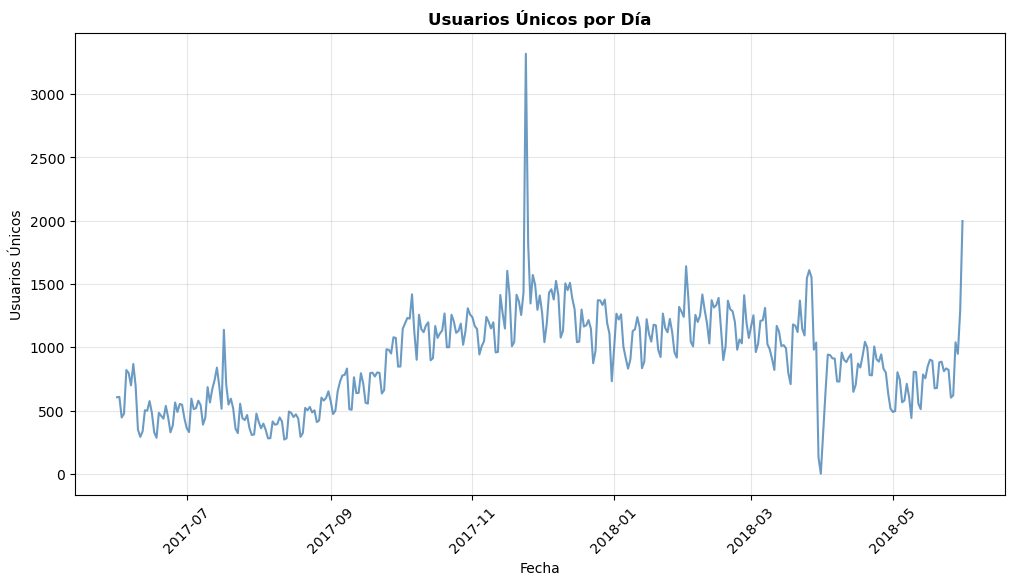

In [28]:
# Gráfico: Usuarios únicos por día
plt.figure(figsize=(12, 6))
plt.plot(pd.to_datetime(daily_users['date']), daily_users['unique_users'],
         color='steelblue', linewidth=1.5, alpha=0.8)
plt.title('Usuarios Únicos por Día', fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Usuarios Únicos')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.show()

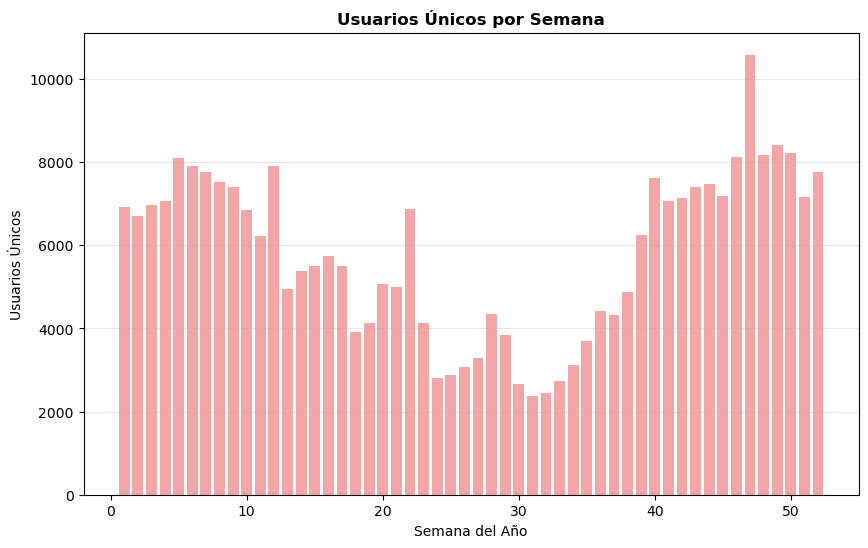

In [29]:
# Gráfico: Usuarios únicos por semana
plt.figure(figsize=(10, 6))
plt.bar(weekly_users['week'], weekly_users['unique_users'],
        color='lightcoral', alpha=0.7)
plt.title('Usuarios Únicos por Semana', fontweight='bold')
plt.xlabel('Semana del Año')
plt.ylabel('Usuarios Únicos')
plt.grid(True, alpha=0.3, axis='y')
plt.show()

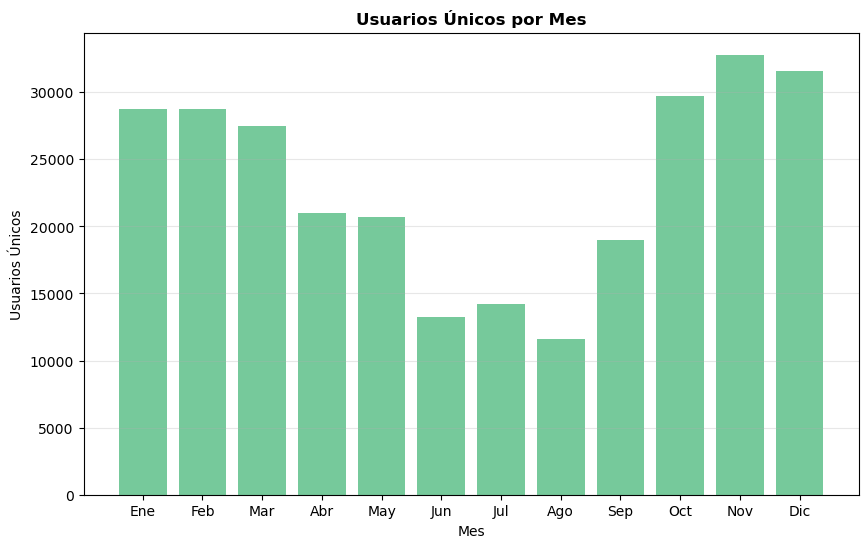

In [30]:
# Gráfico: Usuarios únicos por mes
month_names = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 
               'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

plt.figure(figsize=(10, 6))
plt.bar(range(1, 13), monthly_users['unique_users'], 
        color='mediumseagreen', alpha=0.7)
plt.title('Usuarios Únicos por Mes', fontweight='bold')
plt.xlabel('Mes')
plt.ylabel('Usuarios Únicos')
plt.xticks(range(1, 13), month_names)
plt.grid(True, alpha=0.3, axis='y')
plt.show()

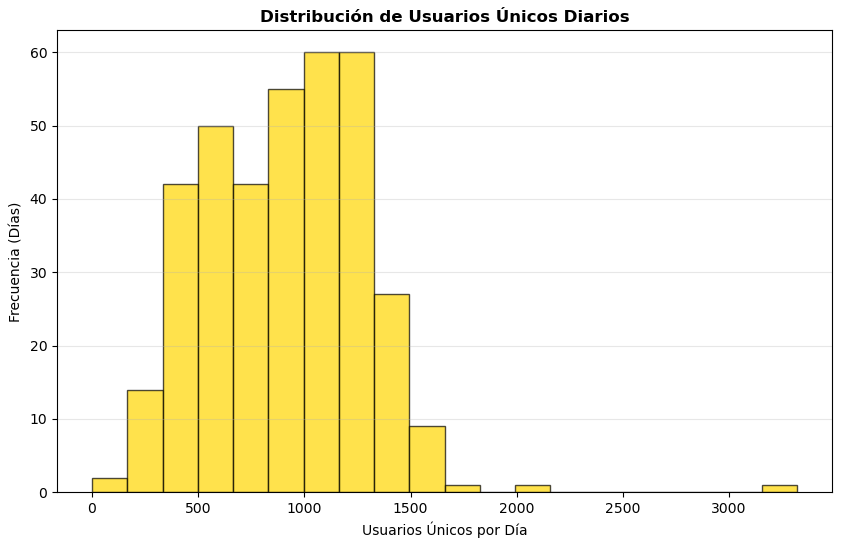

In [31]:
# Gráfico: Distribución de usuarios únicos diarios (histograma)
plt.figure(figsize=(10, 6))
plt.hist(daily_users['unique_users'], bins=20, 
         color='gold', alpha=0.7, edgecolor='black')
plt.title('Distribución de Usuarios Únicos Diarios', fontweight='bold')
plt.xlabel('Usuarios Únicos por Día')
plt.ylabel('Frecuencia (Días)')
plt.grid(True, alpha=0.3, axis='y')
plt.show()

#### Conclusión — Usuarios Únicos en el Tiempo

El análisis de usuarios únicos muestra un comportamiento consistente a lo largo del período evaluado, con **364 días**, **52 semanas** y **12 meses** analizados.

- En promedio, el sitio registró **908 usuarios únicos por día**, **5,825 por semana** y **23,228 por mes**.
- A nivel mensual, se observa una **estacionalidad clara**, con picos de tráfico en los últimos meses del año (octubre a diciembre) y menor actividad durante el verano.
- La agregación semanal suaviza la variabilidad diaria, permitiendo identificar tendencias más estables en el tráfico de usuarios.

Para la visualización de estos patrones:
- Se utilizaron **gráficos de línea** para mostrar la evolución de los usuarios únicos diarios.
- Se emplearon **gráficos de barras** para comparar usuarios únicos por semana y por mes.
- Se construyó un **histograma** para analizar la distribución de usuarios únicos diarios y su variabilidad.

Estos resultados permiten comprender la dinámica temporal del tráfico y sirven como base para análisis posteriores de conversión y comportamiento de usuarios.

#### 2.1.2 ¿Cuántas sesiones hay por día?

In [32]:
# Contar sesiones por día
daily_sessions = visits.groupby('date').size().reset_index()
daily_sessions.columns = ['date', 'sessions']

In [33]:
# Mostrar resumen de sesiones por día
print("=== NÚMERO DE SESIONES POR DÍA ===")
print(f"Total de días analizados: {len(daily_sessions)}")
print(f"Promedio de sesiones por día: {daily_sessions['sessions'].mean():.0f}")
print("\nPrimeros 10 días:")
print(daily_sessions.head(10))

=== NÚMERO DE SESIONES POR DÍA ===
Total de días analizados: 364
Promedio de sesiones por día: 987

Primeros 10 días:
         date  sessions
0  2017-06-01       664
1  2017-06-02       658
2  2017-06-03       477
3  2017-06-04       510
4  2017-06-05       893
5  2017-06-06       875
6  2017-06-07       788
7  2017-06-08       939
8  2017-06-09       755
9  2017-06-10       375


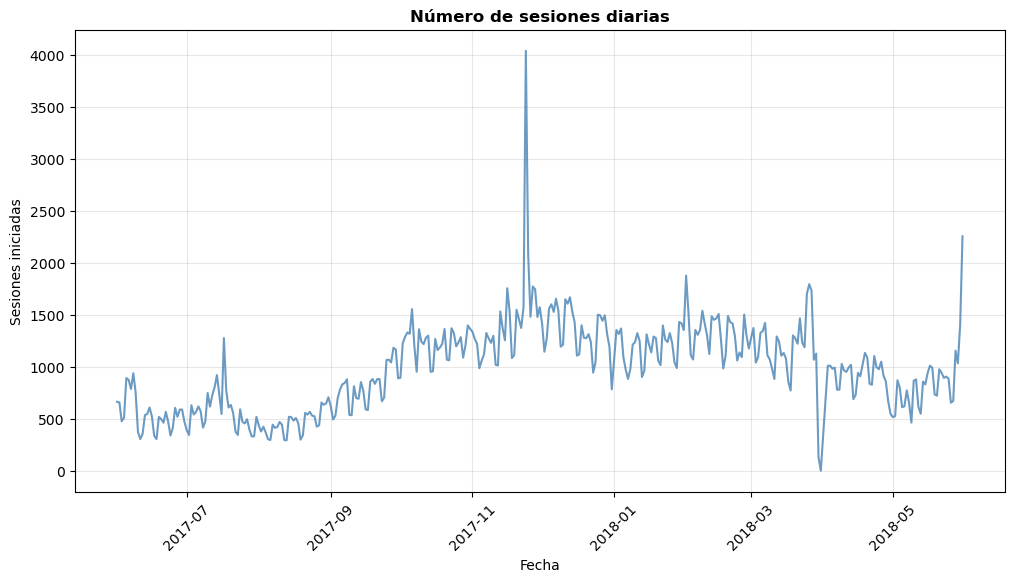

In [34]:
# Gráfico: Número de sesiones por día
plt.figure(figsize=(12, 6))
plt.plot(pd.to_datetime(daily_sessions['date']), daily_sessions['sessions'],
         color='steelblue', linewidth=1.5, alpha=0.8)
plt.title('Número de sesiones diarias', fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Sesiones iniciadas')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.show()

#### Conclusión — Número de Sesiones por Día

El análisis de sesiones diarias revela un patrón de actividad consistente con **987 sesiones promedio por día** durante los **364 días** analizados.

**Hallazgos principales:**
- El sitio web registra un volumen estable de sesiones diarias, con variaciones naturales según la época del año
- La evolución temporal muestra patrones similares a los usuarios únicos, sugiriendo consistencia en el comportamiento de navegación
- Los picos y valles en el gráfico de línea temporal reflejan la estacionalidad típica del negocio

**Relación con usuarios únicos:**
- Con **908 usuarios únicos** y **987 sesiones** promedio por día, obtenemos una **ratio de 1.09 sesiones por usuario**
- Esta métrica indica que la mayoría de usuarios realizan una sola sesión por día, con algunos usuarios regresando para sesiones adicionales

La visualización mediante **gráfico de línea temporal** permite identificar tendencias y patrones estacionales que serán útiles para la planificación de estrategias de marketing y optimización de recursos.

#### 2.1.3. ¿Cuál es la duración de cada sesión?

In [35]:
# Análisis estadístico de duración
duration_stats = visits['session_duration'].describe()

print("Estadísticas de duración por sesión:")
print()
print(duration_stats.round(2))

Estadísticas de duración por sesión:

count    359400.00
mean         10.72
std          16.62
min         -46.00
25%           2.00
50%           5.00
75%          14.00
max         711.00
Name: session_duration, dtype: float64


**Problema detectado:** Se encontraron **valores negativos** en la duración de sesiones (mínimo: -46 minutos), lo cual indica errores en la captura de timestamps.

**Acción requerida:** Es necesario analizar estos valores problemáticos para determinar su impacto en el análisis general.

In [36]:
# Análisis de valores problemáticos
print("Valores negativos:")
print(f"Cantidad: {(visits['session_duration'] < 0).sum()}")
print(f"Porcentaje: {(visits['session_duration'] < 0).mean() * 100:.2f}%")

print("\nValores muy altos (mayor a 60 minutos):")
print(f"Cantidad: {(visits['session_duration'] > 60).sum()}")
print(f"Porcentaje: {(visits['session_duration'] > 60).mean() * 100:.2f}%")

print("\nDistribución de valores altos:")
high_values = visits[visits['session_duration'] > 60]['session_duration']
print(high_values.describe())

Valores negativos:
Cantidad: 2
Porcentaje: 0.00%

Valores muy altos (mayor a 60 minutos):
Cantidad: 6282
Porcentaje: 1.75%

Distribución de valores altos:
count    6282.000000
mean       92.722541
std        44.306572
min        61.000000
25%        68.000000
50%        79.000000
75%       100.000000
max       711.000000
Name: session_duration, dtype: float64


**Hallazgos:**
- **2 valores negativos** (menos del 0.00% de los datos)
- **6,282 valores muy altos** (>60 min, representando 1.75% de las sesiones)

**Conclusión:** Dado el bajo porcentaje de valores anómalos, se mantendrán todos los datos documentando estos hallazgos para transparencia en el análisis.

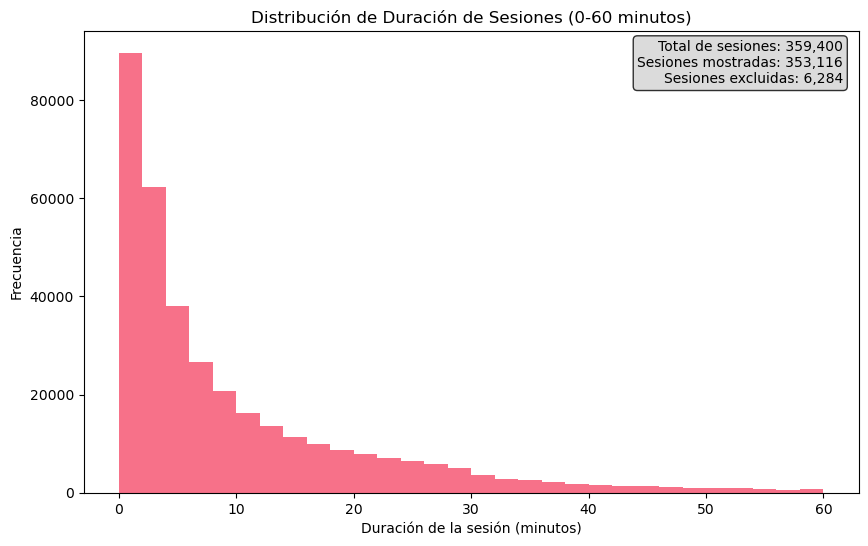

In [37]:
# Filtrar datos normales para mostrar histograma
normal_sessions = visits[(visits['session_duration'] >= 0) & (visits['session_duration'] <= 60)]
# Calcular datos excluidos
total_sessions = len(visits)
normal_sessions_count = len(normal_sessions)
excluded_sessions = total_sessions - normal_sessions_count

plt.figure(figsize=(10, 6))  
plt.hist(normal_sessions['session_duration'], bins=30)  

plt.title('Distribución de Duración de Sesiones (0-60 minutos)')
plt.xlabel('Duración de la sesión (minutos)')
plt.ylabel('Frecuencia')

# Agregar información sobre datos excluidos
plt.text(0.98, 0.98, f'Total de sesiones: {total_sessions:,}\nSesiones mostradas: {normal_sessions_count:,}\nSesiones excluidas: {excluded_sessions:,}', 
         transform=plt.gca().transAxes, verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))

plt.show()
 

#### Interpretación de Estadísticas de Duración

**Análisis de los valores estadísticos:**

- **Media: 10.72 minutos** → La sesión promedio dura casi 11 minutos
- **Mediana: 5 minutos** → La mitad de las sesiones duran 5 minutos o menos  
- **75%: 14 minutos** → El 75% de sesiones duran menos de 14 minutos
- **Máximo: 711 minutos** → Hay sesiones extremadamente largas (casi 12 horas)

**Observaciones importantes:**

- La diferencia entre **media (10.72) y mediana (5)** indica que hay sesiones muy largas que elevan el promedio
- La mayoría de usuarios tienen **sesiones cortas** (5 minutos o menos)
- **Valores anómalos detectados**: Se encontraron **2 valores negativos** (mínimo: -46 minutos) y **6,282 sesiones muy largas** (>60 minutos), representando menos del 2% del total de datos
- **Decisión de análisis**: Se mantuvieron **todas las 359,400 sesiones** para preservar la integridad del dataset, documentando los valores atípicos

**Distribución visual:**

El histograma muestra las sesiones de 0-60 minutos (98.25% de los datos), revelando una **distribución altamente sesgada hacia la derecha** con la mayoría de sesiones concentradas en los primeros 15 minutos.

**Implicaciones para el negocio:**

- Los usuarios tienden a tener **sesiones breves y enfocadas**, sugiriendo navegación eficiente o búsqueda específica
- Existe un segmento pequeño pero significativo de usuarios con **sesiones muy largas** que podrían representar usuarios altamente comprometidos o casos de uso específicos
- Los **valores negativos requieren investigación técnica** para corregir problemas en la captura de timestamps del sistema

#### 2.1.4. Análisis de retención de usuarios

In [38]:
# Contar sesiones por usuario
user_sessions = visits.groupby('uid').size().reset_index()
user_sessions.columns = ['uid', 'session_count']

# Análisis de frecuencia de retorno
return_frequency = user_sessions['session_count'].value_counts().sort_index()

In [39]:
# Crear tabla de retención 
retention_table = pd.DataFrame({
    'sessions': return_frequency.index,
    'users': return_frequency.values,
    'pct': (return_frequency.values / return_frequency.sum() * 100).round(2)
})

# Agregar columna de retención acumulada
retention_table['cumulative_pct'] = retention_table['pct'].cumsum()

print("=== TABLA DE RETENCIÓN DE USUARIOS ===")
print(retention_table.head(10))

=== TABLA DE RETENCIÓN DE USUARIOS ===
   sessions   users    pct  cumulative_pct
0         1  176041  77.15           77.15
1         2   30926  13.55           90.70
2         3   10184   4.46           95.16
3         4    4357   1.91           97.07
4         5    2283   1.00           98.07
5         6    1243   0.54           98.61
6         7     807   0.35           98.96
7         8     513   0.22           99.18
8         9     356   0.16           99.34
9        10     239   0.10           99.44


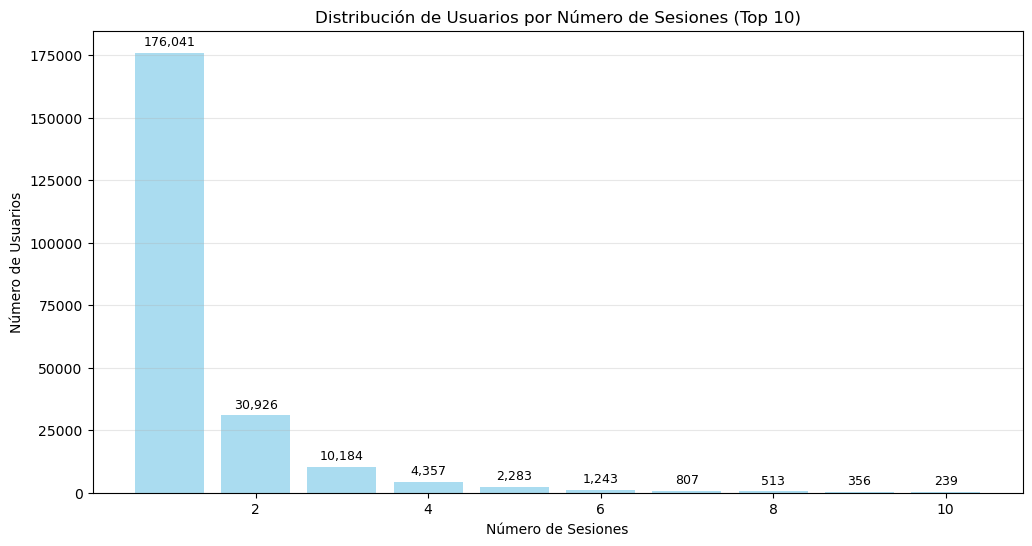

In [40]:
# Limitar a primeras 10 categorías para mejor visualización
plt.figure(figsize=(12, 6))
top_sessions = return_frequency.head(10)
plt.bar(top_sessions.index, top_sessions.values, color='skyblue', alpha=0.7)
plt.title('Distribución de Usuarios por Número de Sesiones (Top 10)')
plt.xlabel('Número de Sesiones')
plt.ylabel('Número de Usuarios')
plt.grid(True, alpha=0.3, axis='y')

# Agregar valores en las barras para mejor legibilidad
for i, v in enumerate(top_sessions.values):
    plt.text(top_sessions.index[i], v + max(top_sessions.values) * 0.01, 
             f'{v:,}', ha='center', va='bottom', fontsize=9)

plt.show()

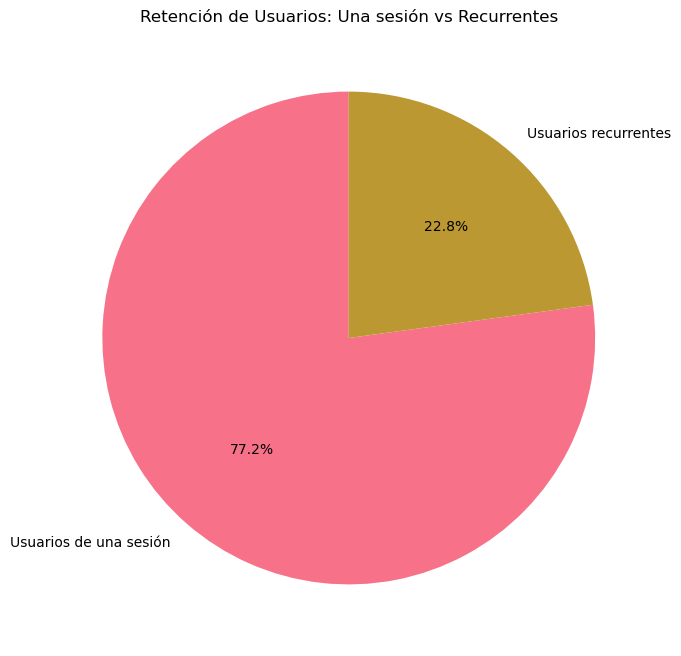

In [41]:
# Categorizar usuarios
single_users = (user_sessions['session_count'] == 1).sum()
returning_users = (user_sessions['session_count'] > 1).sum()

plt.figure(figsize=(8, 8))
labels = ['Usuarios de una sesión', 'Usuarios recurrentes']
sizes = [single_users, returning_users]
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Retención de Usuarios: Una sesión vs Recurrentes')
plt.show()

#### Conclusión — Retención de Usuarios

El análisis de retención muestra una **alta concentración de usuarios de una sola sesión**, donde el **77.15%** de los usuarios no regresa después de su primera visita. Esto indica una **baja retención inicial**, especialmente crítica en las primeras interacciones con el producto.

Aproximadamente **22.85% de los usuarios son recurrentes** (dos o más sesiones), aunque la retención disminuye rápidamente conforme aumenta el número de sesiones. Más del **90% de los usuarios** se concentra en las primeras dos sesiones, y a partir de la quinta sesión la proporción de usuarios es marginal (<1% por nivel).

Los gráficos de barras y el gráfico circular refuerzan este patrón, mostrando una **distribución fuertemente sesgada hacia pocas sesiones**, mientras que la tabla de retención evidencia que el valor acumulado se alcanza rápidamente en los primeros niveles.

Desde una perspectiva de negocio, estos resultados sugieren la necesidad de **mejorar la experiencia inicial y las estrategias de retención temprana**, así como identificar y analizar el comportamiento del pequeño grupo de usuarios altamente recurrentes para potenciar su impacto en métricas clave como conversión y revenue.

## Conclusiones Generales — Análisis de Tráfico Web

El análisis del tráfico web permite comprender el comportamiento de los usuarios a lo largo del tiempo, desde la frecuencia de visitas hasta la retención y el nivel de engagement.

En promedio, el sitio registra **908 usuarios únicos y 987 sesiones por día**, lo que resulta en una ratio cercana a **1.09 sesiones por usuario**, indicando que la mayoría de los usuarios realiza una sola sesión diaria. A nivel temporal, se observa una **estacionalidad clara**, con mayor tráfico en los últimos meses del año y menor actividad durante el verano, patrón consistente tanto en usuarios únicos como en sesiones.

El análisis de duración de sesiones muestra que la mayoría de las visitas son **cortas y enfocadas**: la mediana es de **5 minutos**, mientras que la media se eleva a **10.72 minutos** debido a un pequeño grupo de sesiones muy largas. Aunque se detectaron valores atípicos (sesiones negativas y extremadamente largas), estos representan una proporción menor del total y fueron documentados sin excluir datos para mantener la integridad del dataset.

En términos de retención, se identifica un **desafío significativo en las primeras interacciones**, ya que el **77.15% de los usuarios solo tiene una sesión**. No obstante, existe un **segmento reducido pero valioso de usuarios recurrentes** que concentra el valor acumulado y representa una oportunidad clara para estrategias de fidelización.

En conjunto, los resultados sugieren que el tráfico es estable y predecible, pero que el **principal reto del negocio está en mejorar la retención temprana y el engagement inicial**, sentando las bases para análisis posteriores de conversión, revenue y eficiencia de marketing.

### 2.2. Análisis de Ventas 

#### 2.2.1 ¿En qué momento ocurre la primera compra tras la primera visita?

In [42]:
# Obtener primera visita por usuario
first_visits = visits.groupby('uid')['start_ts'].min().reset_index()
first_visits.columns = ['uid', 'first_visit']

# Obtener primera compra por usuario
first_orders = orders.groupby('uid')['buy_ts'].min().reset_index()
first_orders.columns = ['uid', 'first_purchase']

In [43]:
# Unir datos y calcular diferencia en días
conversion_data = first_visits.merge(first_orders, on='uid', how='inner')
conversion_data['days_to_purchase'] = (
    conversion_data['first_purchase'] - conversion_data['first_visit']
).dt.days

In [44]:
# Agregar información de fuente de adquisición
conversion_with_source = conversion_data.merge(
    visits.groupby('uid')['source_id'].first().reset_index(),
    on='uid', how='left'
)

# Análisis de conversión por fuente
conversion_by_source = conversion_with_source.groupby('source_id').agg({
    'days_to_purchase': ['count', 'mean', 'median']
}).round(2)

conversion_by_source.columns = ['users_converted', 'avg_days', 'median_days']
conversion_by_source = conversion_by_source.reset_index()

In [45]:
# Categorizar por períodos de conversión
def categorize_conversion_time(days):
    if days == 0:
        return '0 días (mismo día)'
    elif days == 1:
        return '1 día'
    elif 2 <= days <= 7:
        return '2-7 días'
    elif 8 <= days <= 30:
        return '8-30 días'
    else:
        return '30+ días'

conversion_data['conversion_period'] = (
    conversion_data['days_to_purchase'].apply(categorize_conversion_time)
)

# Calcular tasas de conversión por período
conversion_periods = conversion_data['conversion_period'].value_counts()
conversion_periods_pct = (conversion_periods / conversion_periods.sum() * 100).round(2)

In [46]:
# Obtener la fuente de la primera visita de cada usuario
first_visit_source = visits.groupby('uid').agg({
    'start_ts': 'min',
    'source_id': 'first'  # Toma la fuente de la primera visita
}).reset_index()

# Unir con datos de conversión
conversion_with_source = conversion_data.merge(
    first_visit_source[['uid', 'source_id']], 
    on='uid', 
    how='left'
)

In [47]:
# Estadísticas de conversión por fuente
cohort_analysis = conversion_with_source.groupby('source_id').agg({
    'days_to_purchase': ['count', 'mean', 'median', 'std']
}).round(2)

cohort_analysis.columns = ['users_converted', 'avg_days', 'median_days', 'std']
cohort_analysis = cohort_analysis.reset_index()

In [48]:
# Ver estadísticas básicas de conversión
print("=== ESTADÍSTICAS BÁSICAS DE CONVERSIÓN ===")
print(f"Total usuarios que compraron: {len(conversion_data):,}")
print(f"Días promedio hasta primera compra: {conversion_data['days_to_purchase'].mean():.1f}")
print(f"Días mediana hasta primera compra: {conversion_data['days_to_purchase'].median():.1f}")
print()
print(conversion_data['days_to_purchase'].describe().round(2))

=== ESTADÍSTICAS BÁSICAS DE CONVERSIÓN ===
Total usuarios que compraron: 36,523
Días promedio hasta primera compra: 16.7
Días mediana hasta primera compra: 0.0

count    36523.00
mean        16.73
std         46.96
min          0.00
25%          0.00
50%          0.00
75%          2.00
max        363.00
Name: days_to_purchase, dtype: float64


In [49]:
# Ver análisis por períodos de tiempo
print("=== CONVERSIÓN POR PERÍODOS ===")
print(conversion_periods_pct)

=== CONVERSIÓN POR PERÍODOS ===
conversion_period
0 días (mismo día)    72.18
30+ días              13.42
8-30 días              5.96
2-7 días               5.66
1 día                  2.77
Name: count, dtype: float64


In [50]:
# 3. Ver análisis por fuentes (cohortes)
print("=== ANÁLISIS POR FUENTES ===")
print(cohort_analysis)

=== ANÁLISIS POR FUENTES ===
   source_id  users_converted  avg_days  median_days    std
0          1             3743     14.51          0.0  42.09
1          2             4323     21.68          0.0  52.33
2          3             9138     16.05          0.0  47.15
3          4             9823     16.64          0.0  46.34
4          5             6839     13.18          0.0  41.89
5          7                1      0.00          0.0    NaN
6          9             1415     32.17          0.0  62.20
7         10             1241     13.81          0.0  46.09


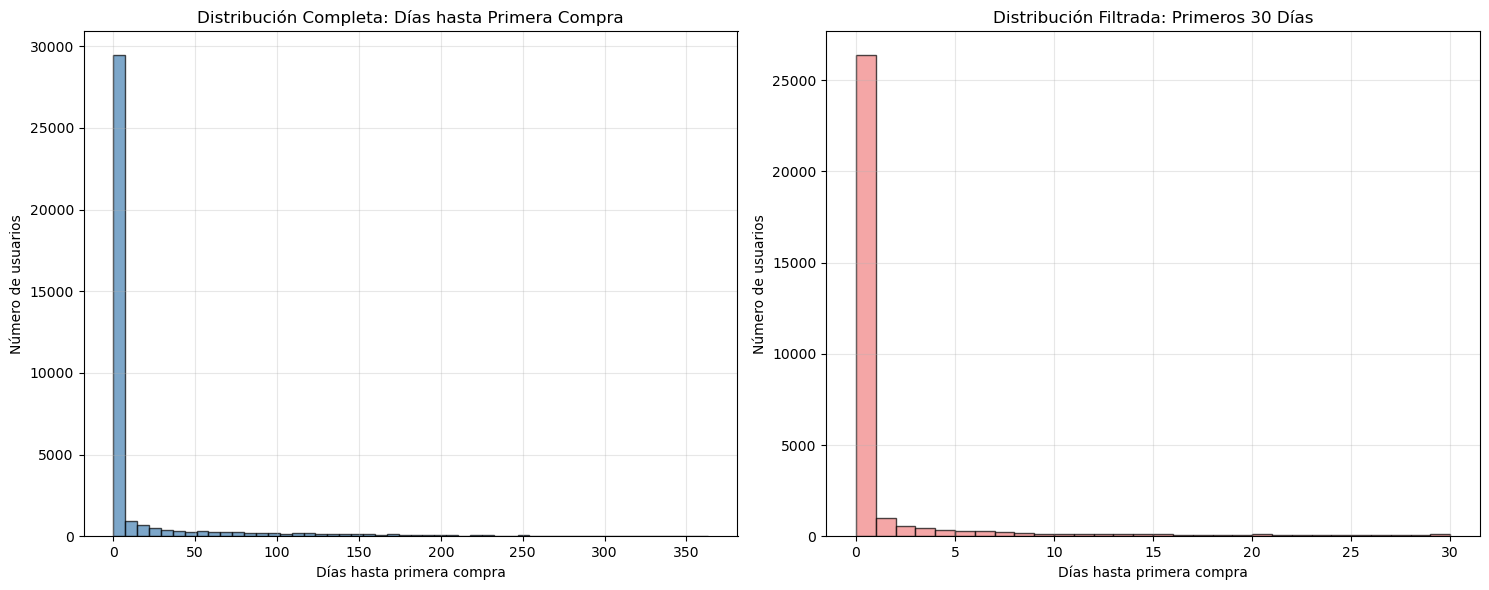

In [51]:
# Crear figura con dos subgráficos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Histograma 1: Distribución completa (0-363 días)
ax1.hist(conversion_data['days_to_purchase'], bins=50, 
         color='steelblue', alpha=0.7, edgecolor='black')
ax1.set_title('Distribución Completa: Días hasta Primera Compra')
ax1.set_xlabel('Días hasta primera compra')
ax1.set_ylabel('Número de usuarios')
ax1.grid(True, alpha=0.3)

# Histograma 2: Primeros 30 días (filtrado)
filtered_data = conversion_data[conversion_data['days_to_purchase'] <= 30]
ax2.hist(filtered_data['days_to_purchase'], bins=30, 
         color='lightcoral', alpha=0.7, edgecolor='black')
ax2.set_title('Distribución Filtrada: Primeros 30 Días')
ax2.set_xlabel('Días hasta primera compra')
ax2.set_ylabel('Número de usuarios')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Conclusión — La Conversión Ocurre Principalmente el Primer Día

El análisis de conversión revela una **fuerte intención de compra inmediata** por parte de los usuarios. Del total de **36,523 usuarios que realizaron al menos una compra**, el **72.18% convirtió el mismo día de su primera visita**, lo que indica que una gran proporción del tráfico llega con una decisión de compra prácticamente tomada.

La distribución del tiempo hasta la primera compra está altamente sesgada hacia valores bajos: la **mediana es de 0 días** y el **75% de los usuarios compra en los primeros 2 días**, mientras que la media (16.7 días) se ve influenciada por un grupo reducido de usuarios que tardan significativamente más en convertir. Este patrón sugiere la coexistencia de dos segmentos claros: usuarios de conversión inmediata y usuarios que requieren mayor tiempo o estímulos adicionales.

Los usuarios que no compran el primer día muestran una **caída pronunciada en la probabilidad de conversión**. Aunque existe un grupo que convierte después de 30 días (13.42%), este comportamiento es menos frecuente y probablemente requiere estrategias de remarketing más específicas para ser activado.

El análisis por fuente confirma este patrón: en todas las fuentes relevantes la **mediana de días hasta la compra es 0**, reforzando la idea de intención inmediata, aunque con diferencias en el tiempo promedio, lo que sugiere variaciones en la calidad o el tipo de tráfico entre canales.

Desde una perspectiva de marketing, estos resultados indican que:
- Es clave **optimizar la experiencia del primer día**, ya que concentra la mayor parte de las conversiones.
- Las campañas deben enfocarse en **capturar y convertir la intención inmediata** (ofertas claras, mensajes directos, UX optimizada).
- Para los usuarios que no convierten en los primeros días, se justifica el uso de **estrategias de remarketing y nurturing**, priorizando ventanas cortas de tiempo donde la probabilidad de conversión aún es relevante.

En conjunto, la conversión inmediata es el principal motor de ventas del negocio, y cualquier optimización en las primeras interacciones tendrá un impacto directo y significativo en los resultados.

#### 2.2.2. ¿Cuántos pedidos hacen durante un período de tiempo dado?

In [52]:
# Pedidos por día
daily_orders = orders.groupby('buy_date').size().reset_index()
daily_orders.columns = ['date', 'orders']

# Pedidos por semana  
weekly_orders = orders.groupby('buy_week').size().reset_index()
weekly_orders.columns = ['week', 'orders']

# Pedidos por mes
monthly_orders = orders.groupby('buy_month').size().reset_index()
monthly_orders.columns = ['month', 'orders']

In [53]:
# Mostrar resumen de pedidos por día
print("=== PEDIDOS POR DÍA ===")
print(f"Total de días analizados: {len(daily_orders)}")
print(f"Promedio de pedidos por día: {daily_orders['orders'].mean():.0f}")
print("\nPrimeros 10 días:")
print(daily_orders.head(10))

print("\n" + "="*50)

# Mostrar resumen de pedidos por semana  
print("=== PEDIDOS POR SEMANA ===")
print(f"Total de semanas analizadas: {len(weekly_orders)}")
print(f"Promedio de pedidos por semana: {weekly_orders['orders'].mean():.0f}")
print("\nPrimeras 10 semanas:")
print(weekly_orders.head(10))

print("\n" + "="*50)

# Mostrar resumen de pedidos por mes
print("=== PEDIDOS POR MES ===")
print(f"Total de meses analizados: {len(monthly_orders)}")
print(f"Promedio de pedidos por mes: {monthly_orders['orders'].mean():.0f}")
print("\nTodos los meses:")
print(monthly_orders)

=== PEDIDOS POR DÍA ===
Total de días analizados: 364
Promedio de pedidos por día: 139

Primeros 10 días:
         date  orders
0  2017-06-01      96
1  2017-06-02     111
2  2017-06-03      67
3  2017-06-04      66
4  2017-06-05     161
5  2017-06-06     198
6  2017-06-07     197
7  2017-06-08     181
8  2017-06-09     131
9  2017-06-10      42

=== PEDIDOS POR SEMANA ===
Total de semanas analizadas: 52
Promedio de pedidos por semana: 970

Primeras 10 semanas:
   week  orders
0     1    1006
1     2     942
2     3     991
3     4    1128
4     5    1442
5     6    1272
6     7    1368
7     8    1347
8     9    1252
9    10    1293

=== PEDIDOS POR MES ===
Total de meses analizados: 12
Promedio de pedidos por mes: 4201

Todos los meses:
    month  orders
0       1    4721
1       2    5281
2       3    5326
3       4    3273
4       5    4346
5       6    2355
6       7    2363
7       8    1807
8       9    3387
9      10    5679
10     11    5659
11     12    6218


In [54]:
# Configurar el estilo de los gráficos
plt.style.use('default')
sns.set_palette("husl")

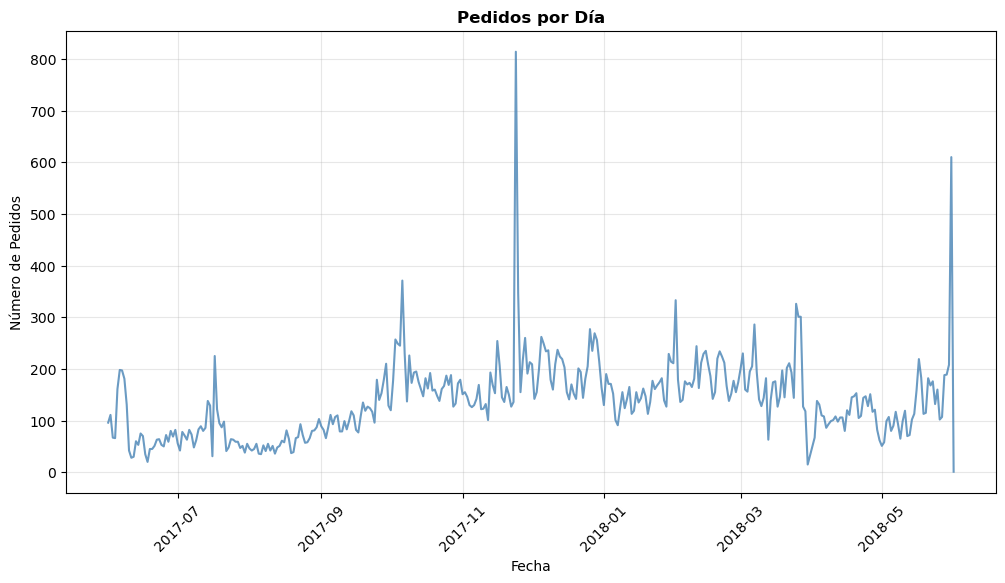

In [55]:
# Gráfico: Pedidos por día
plt.figure(figsize=(12, 6))
plt.plot(pd.to_datetime(daily_orders['date']), daily_orders['orders'],
         color='steelblue', linewidth=1.5, alpha=0.8)
plt.title('Pedidos por Día', fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Número de Pedidos')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.show()

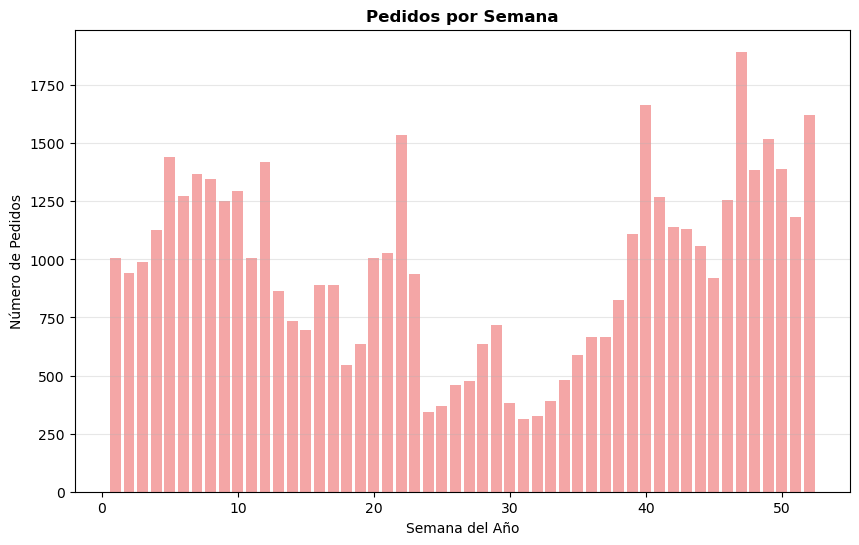

In [56]:
# Gráfico: Pedidos por semana
plt.figure(figsize=(10, 6))
plt.bar(weekly_orders['week'], weekly_orders['orders'],
         color='lightcoral', alpha=0.7)
plt.title('Pedidos por Semana', fontweight='bold')
plt.xlabel('Semana del Año')
plt.ylabel('Número de Pedidos')
plt.grid(True, alpha=0.3, axis='y')
plt.show()

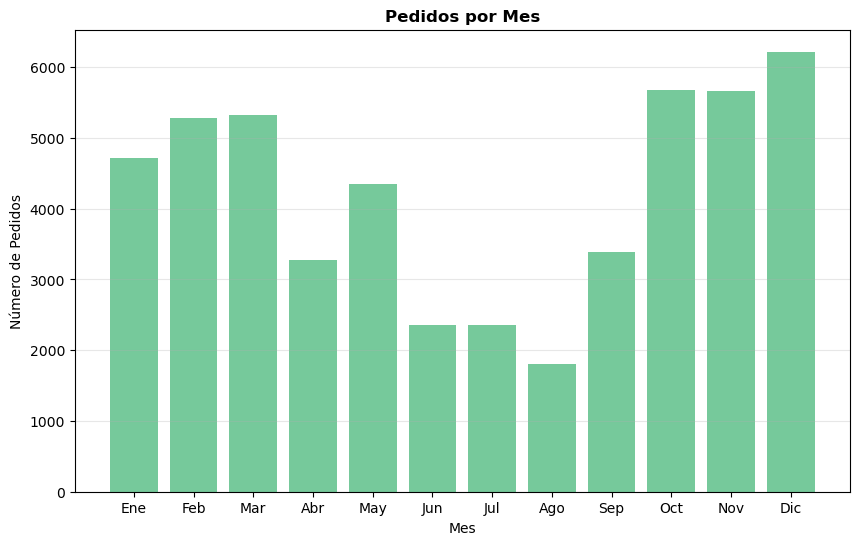

In [57]:
# Gráfico: Pedidos por mes
month_names = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
               'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
plt.figure(figsize=(10, 6))
plt.bar(range(1, 13), monthly_orders['orders'],
         color='mediumseagreen', alpha=0.7)
plt.title('Pedidos por Mes', fontweight='bold')
plt.xlabel('Mes')
plt.ylabel('Número de Pedidos')
plt.xticks(range(1, 13), month_names)
plt.grid(True, alpha=0.3, axis='y')
plt.show()

#### Conclusión — Los Pedidos Siguen un Patrón Estacional y Predecible

El análisis del volumen de pedidos muestra un comportamiento **estable en el corto plazo** y una **estacionalidad clara a nivel mensual**, consistente con los patrones observados en el tráfico.

En promedio, el sitio registra **139 pedidos por día**, **970 pedidos por semana** y **4,201 pedidos por mes**. A nivel diario y semanal, la agregación suaviza la variabilidad, permitiendo identificar una tendencia relativamente constante en el volumen de pedidos.

A nivel mensual, se observa una **concentración de pedidos en los últimos meses del año**, con un crecimiento marcado entre **octubre y diciembre**, donde se alcanzan los valores más altos del período. En contraste, los meses de **verano (junio a agosto)** presentan el menor volumen de pedidos, reflejando un efecto estacional.

Los gráficos de línea (pedidos diarios) y de barras (pedidos semanales y mensuales) confirman estos patrones, mostrando una evolución coherente con el comportamiento de los usuarios y reforzando la relación entre tráfico, conversión y volumen de ventas.

En términos de negocio, estos resultados permiten **anticipar picos de demanda**, planificar inventario y optimizar campañas de marketing en los períodos de mayor volumen, así como identificar meses de baja actividad donde pueden aplicarse estrategias de activación.

#### 2.2.3. ¿Cuál es el tamaño promedio de compra?

In [58]:
# Análisis estadístico detallado del revenue
print("=== ANÁLISIS DETALLADO DEL TAMAÑO DE COMPRA ===")
print(f"Total de transacciones: {len(orders):,}")
print(f"Revenue total: ${orders['revenue'].sum():,.2f}")
print()

# Estadísticas descriptivas expandidas
revenue_stats = orders['revenue'].describe()
print("Estadísticas básicas:")
for stat, value in revenue_stats.items():
    print(f"  {stat.capitalize()}: ${value:.2f}")

print()
print("Estadísticas adicionales:")
print(f"  Moda: ${orders['revenue'].mode()[0]:.2f}")
print(f"  Rango: ${orders['revenue'].max() - orders['revenue'].min():.2f}")
print(f"  Coeficiente de variación: {(orders['revenue'].std() / orders['revenue'].mean()):.2f}")

=== ANÁLISIS DETALLADO DEL TAMAÑO DE COMPRA ===
Total de transacciones: 50,415
Revenue total: $252,057.20

Estadísticas básicas:
  Count: $50415.00
  Mean: $5.00
  Std: $21.82
  Min: $0.00
  25%: $1.22
  50%: $2.50
  75%: $4.89
  Max: $2633.28

Estadísticas adicionales:
  Moda: $1.83
  Rango: $2633.28
  Coeficiente de variación: 4.36


In [59]:
# Análisis de percentiles más detallado
percentages = [10, 20, 30, 40, 50, 60, 70, 80, 90, 95, 99]
print("\n=== ANÁLISIS DE PERCENTILES ===")
for p in percentages:
    value = orders['revenue'].quantile(p/100)
    print(f"  {p}% de las compras ≤ ${value:.2f}")


=== ANÁLISIS DE PERCENTILES ===
  10% de las compras ≤ $0.61
  20% de las compras ≤ $1.10
  30% de las compras ≤ $1.53
  40% de las compras ≤ $2.00
  50% de las compras ≤ $2.50
  60% de las compras ≤ $3.36
  70% de las compras ≤ $4.28
  80% de las compras ≤ $6.11
  90% de las compras ≤ $9.17
  95% de las compras ≤ $13.75
  99% de las compras ≤ $36.67


In [60]:
# Análisis de outliers
print("\n=== ANÁLISIS DE VALORES EXTREMOS ===")
q1 = orders['revenue'].quantile(0.25)
q3 = orders['revenue'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = orders[(orders['revenue'] < lower_bound) | (orders['revenue'] > upper_bound)]
print(f"  Outliers detectados: {len(outliers):,} ({len(outliers)/len(orders)*100:.2f}%)")
print(f"  Compras > $50: {(orders['revenue'] > 50).sum():,}")
print(f"  Compras > $100: {(orders['revenue'] > 100).sum():,}")


=== ANÁLISIS DE VALORES EXTREMOS ===
  Outliers detectados: 3,990 (7.91%)
  Compras > $50: 308
  Compras > $100: 113


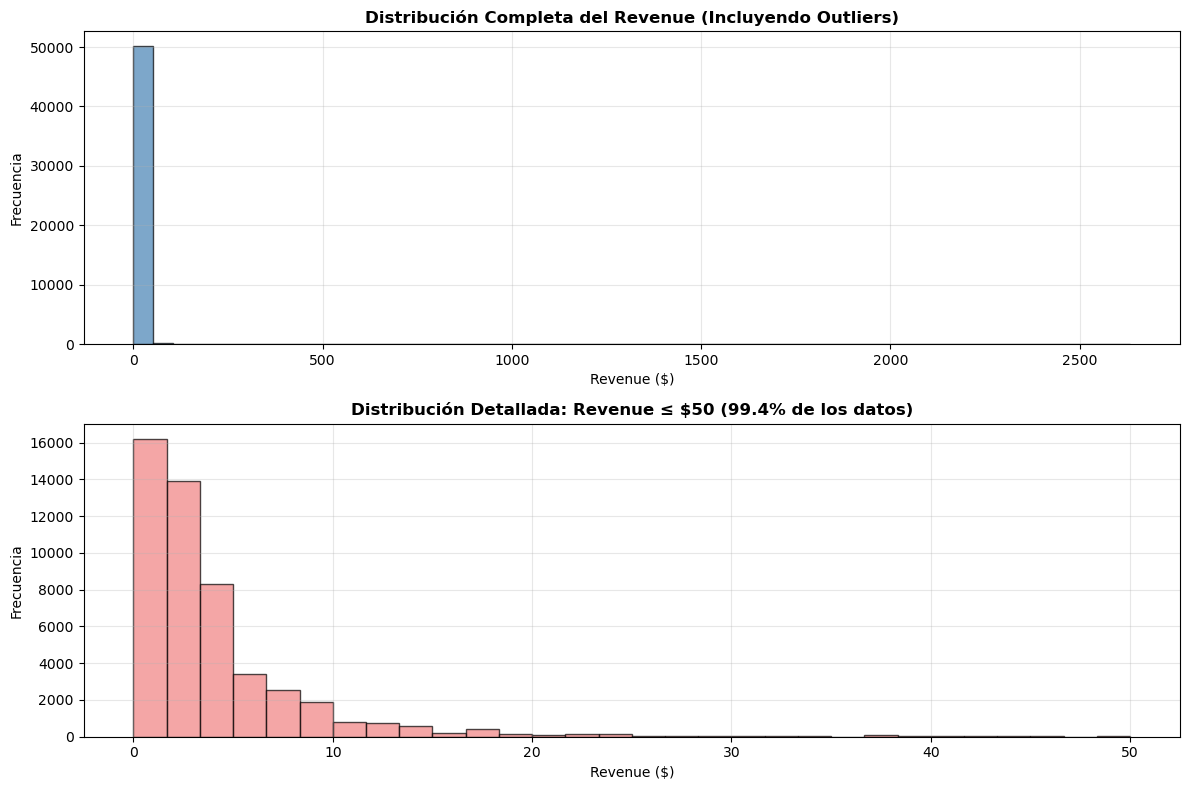

In [61]:
# Crear histograma 
plt.figure(figsize=(12, 8))

# Subplot 1: Distribución completa (con outliers)
plt.subplot(2, 1, 1)
plt.hist(orders['revenue'], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
plt.title('Distribución Completa del Revenue (Incluyendo Outliers)', fontweight='bold')
plt.xlabel('Revenue ($)')
plt.ylabel('Frecuencia')
plt.grid(True, alpha=0.3)

# Subplot 2: Zoom a los primeros $50 para ver detalle
plt.subplot(2, 1, 2)
revenue_filtered = orders[orders['revenue'] <= 50]['revenue']
plt.hist(revenue_filtered, bins=30, color='lightcoral', alpha=0.7, edgecolor='black')
plt.title(f'Distribución Detallada: Revenue ≤ $50 ({len(revenue_filtered)/len(orders)*100:.1f}% de los datos)', fontweight='bold')
plt.xlabel('Revenue ($)')
plt.ylabel('Frecuencia')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [62]:
# Análisis adicional de los outliers
print("=== ANÁLISIS DETALLADO DE OUTLIERS ===")
high_value_purchases = orders[orders['revenue'] > upper_bound]
print(f"Compras de alto valor (>${upper_bound:.2f}): {len(high_value_purchases):,}")
print(f"Revenue promedio de outliers: ${high_value_purchases['revenue'].mean():.2f}")
print(f"Contribución al revenue total: {(high_value_purchases['revenue'].sum() / orders['revenue'].sum() * 100):.1f}%")

=== ANÁLISIS DETALLADO DE OUTLIERS ===
Compras de alto valor (>$10.39): 3,990
Revenue promedio de outliers: $28.07
Contribución al revenue total: 44.4%


#### Conclusión — El Tamaño Promedio de Compra es Bajo y Altamente Asimétrico

El análisis del tamaño de compra muestra que el **valor típico de las transacciones es bajo**, pero con una **distribución fuertemente sesgada hacia la derecha** debido a un pequeño grupo de compras de alto valor.

Aunque el **promedio de compra es de \$5.00**, este valor está fuertemente influenciado por outliers. La **mediana es de \$2.50** y el **75% de las compras no supera los \$4.89**, lo que indica que la mayoría de los usuarios realiza compras pequeñas. Esto se refuerza con la moda de **\$1.83** y con los percentiles, donde el **90% de las compras es menor o igual a \$9.17**.

El coeficiente de variación (**4.36**) confirma una **alta dispersión**, y el análisis de valores extremos muestra que solo el **7.91% de las transacciones** corresponde a compras de alto valor. Sin embargo, este pequeño segmento es altamente relevante, ya que **contribuye con el 44.4% del revenue total**, con un revenue promedio de **$28.07** por transacción.

Desde una perspectiva de negocio, estos resultados sugieren la coexistencia de dos comportamientos claros:
- Un volumen alto de **compras pequeñas y frecuentes**, que sostiene la base de transacciones.
- Un segmento reducido de **compras de alto valor**, que concentra una parte significativa de los ingresos.

Esto abre oportunidades para **estrategias de upselling y cross-selling** orientadas a aumentar el ticket promedio, así como para identificar y retener a los usuarios de alto valor.

#### 2.2.4. ¿Cuánto valor monetario aporta cada cliente durante su relación con la empresa?

In [63]:
# LTV por cliente
ltv_per_client = orders.groupby('uid')['revenue'].sum()

print("=== ANÁLISIS DEL CUSTOMER LIFETIME VALUE (LTV) ===")
print(f"Total de clientes únicos: {len(ltv_per_client):,}")
print(f"LTV promedio: ${ltv_per_client.mean():.2f}")
print()
print("Estadísticas descriptivas:")
print(ltv_per_client.describe().round(2))

=== ANÁLISIS DEL CUSTOMER LIFETIME VALUE (LTV) ===
Total de clientes únicos: 36,523
LTV promedio: $6.90

Estadísticas descriptivas:
count    36523.00
mean         6.90
std         88.13
min          0.00
25%          1.47
50%          3.05
75%          5.80
max      11810.18
Name: revenue, dtype: float64


In [64]:
# Análisis de percentiles más detallado
percentages = [10, 20, 30, 40, 50, 60, 70, 80, 90, 95, 99]
print("\n=== ANÁLISIS DE PERCENTILES DEL LTV ===")
for p in percentages:
    value = ltv_per_client.quantile(p/100)
    print(f"  {p}% de los clientes ≤ ${value:.2f}")


=== ANÁLISIS DE PERCENTILES DEL LTV ===
  10% de los clientes ≤ $0.73
  20% de los clientes ≤ $1.22
  30% de los clientes ≤ $1.83
  40% de los clientes ≤ $2.33
  50% de los clientes ≤ $3.05
  60% de los clientes ≤ $3.67
  70% de los clientes ≤ $4.89
  80% de los clientes ≤ $6.72
  90% de los clientes ≤ $10.75
  95% de los clientes ≤ $16.25
  99% de los clientes ≤ $44.23


In [65]:
# Análisis de outliers y concentración
q1 = ltv_per_client.quantile(0.25)
q3 = ltv_per_client.quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

high_value_clients = ltv_per_client[ltv_per_client > upper_bound]
print(f"\n=== ANÁLISIS DE CONCENTRACIÓN ===")
print(f"Clientes de alto valor (>${upper_bound:.2f}): {len(high_value_clients):,}")
print(f"LTV promedio de clientes de alto valor: ${high_value_clients.mean():.2f}")
print(f"Contribución al revenue total: {(high_value_clients.sum() / ltv_per_client.sum() * 100):.1f}%")


=== ANÁLISIS DE CONCENTRACIÓN ===
Clientes de alto valor (>$12.29): 2,719
LTV promedio de clientes de alto valor: $49.20
Contribución al revenue total: 53.1%


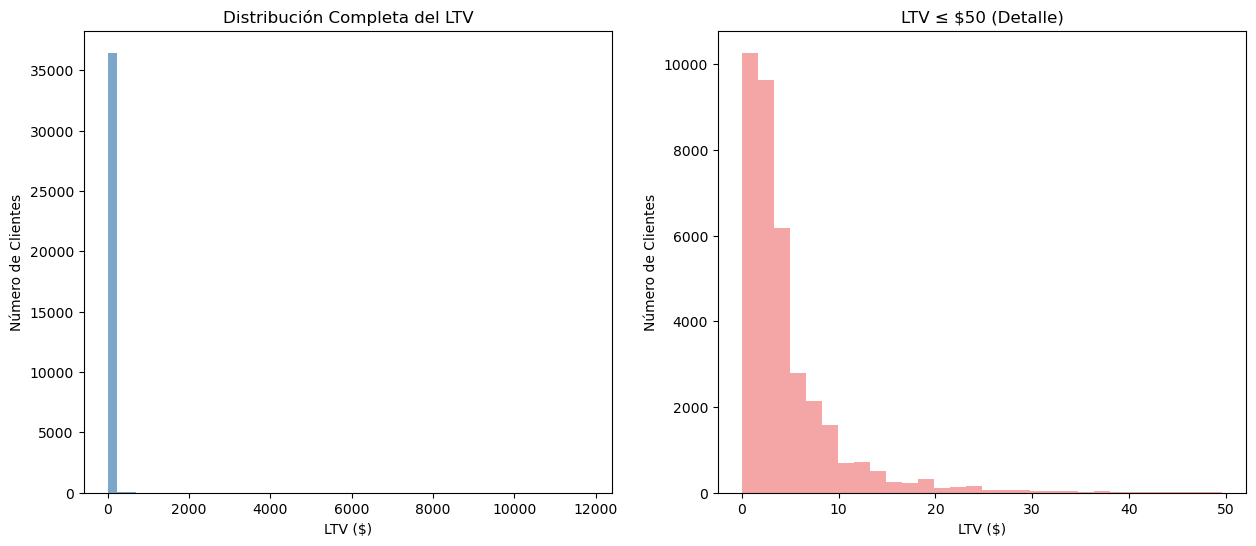

In [66]:
# Histograma con dos vistas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Vista completa
ax1.hist(ltv_per_client, bins=50, color='steelblue', alpha=0.7)
ax1.set_title('Distribución Completa del LTV')
ax1.set_xlabel('LTV ($)')
ax1.set_ylabel('Número de Clientes')

# Vista filtrada (primeros $50)
ltv_filtered = ltv_per_client[ltv_per_client <= 50]
ax2.hist(ltv_filtered, bins=30, color='lightcoral', alpha=0.7)
ax2.set_title('LTV ≤ $50 (Detalle)')
ax2.set_xlabel('LTV ($)')
ax2.set_ylabel('Número de Clientes')

plt.show()

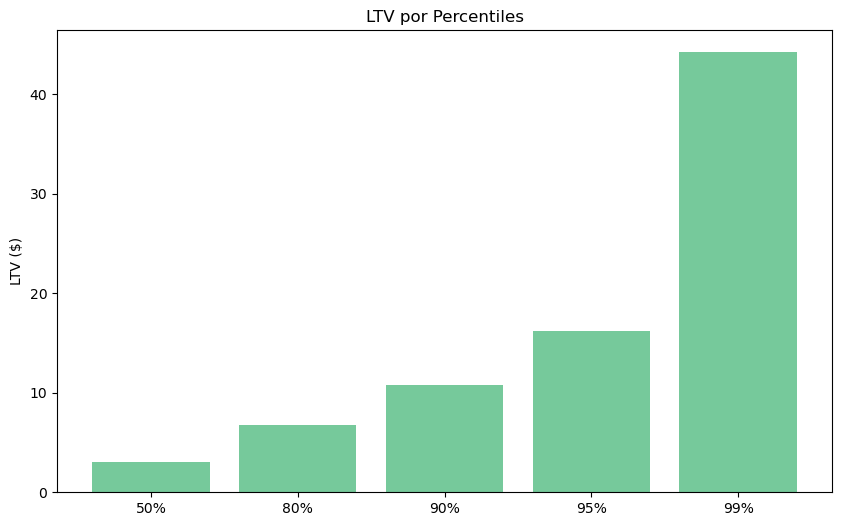

In [67]:
# Percentiles clave
percentiles = [50, 80, 90, 95, 99]
values = [ltv_per_client.quantile(p/100) for p in percentiles]

plt.figure(figsize=(10, 6))
plt.bar([f'{p}%' for p in percentiles], values, color='mediumseagreen', alpha=0.7)
plt.title('LTV por Percentiles')
plt.ylabel('LTV ($)')

plt.show()

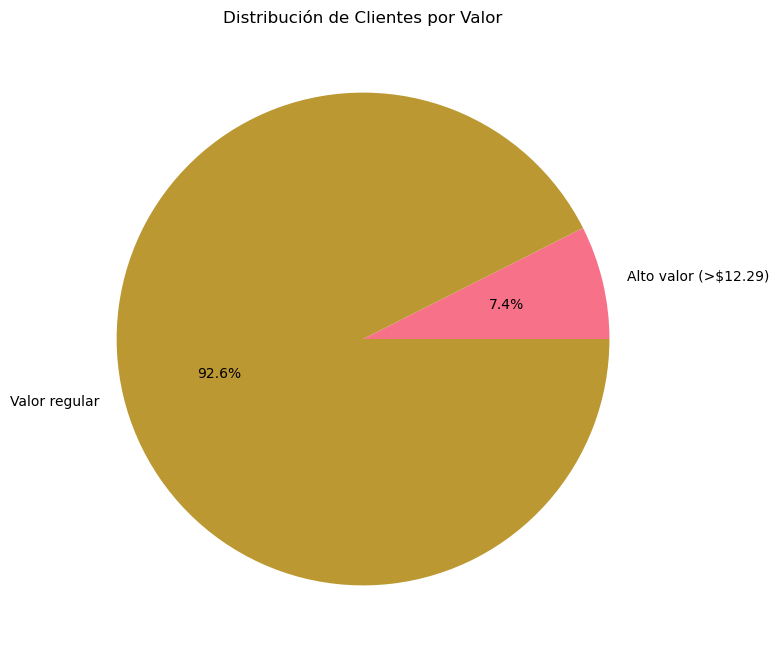

In [68]:
# Clientes alto valor vs resto
high_value_count = len(high_value_clients)
regular_count = len(ltv_per_client) - high_value_count

plt.figure(figsize=(8, 8))
plt.pie([high_value_count, regular_count], 
        labels=['Alto valor (>$12.29)', 'Valor regular'],
        autopct='%1.1f%%')
plt.title('Distribución de Clientes por Valor')
plt.show()

#### Conclusión — El Valor por Cliente es Bajo en Promedio, pero Altamente Concentrado

El análisis del **Customer Lifetime Value (LTV)** muestra que el **valor monetario promedio por cliente es de \$6.90**, aunque esta cifra está fuertemente influenciada por un pequeño grupo de clientes de alto valor. La **mediana de LTV es de \$3.05**, y el **75% de los clientes no supera los \$5.80**, lo que indica que la mayoría de los clientes genera un valor limitado a lo largo de su relación con la empresa.

La distribución del LTV es **altamente asimétrica**, con una desviación estándar elevada (\$88.13) y valores extremos que alcanzan hasta **\$11,810.18**, confirmando una fuerte concentración del revenue. Los percentiles refuerzan este patrón: el **90% de los clientes tiene un LTV menor o igual a \$10.75**, mientras que solo un **1% supera los \$44.23**.

El análisis de concentración revela que **2,719 clientes de alto valor** (LTV > \$12.29) representan apenas una fracción del total, pero **aportan el 53.1% del revenue**, con un LTV promedio de **\$49.20**. 

Desde una perspectiva de negocio, estos resultados sugieren que el crecimiento no depende solo de aumentar la base de clientes, sino de **identificar, retener y potenciar a los clientes de alto valor**. Estrategias de segmentación, fidelización y personalización orientadas a este grupo pueden tener un impacto desproporcionadamente alto en los ingresos totales.

#### Conclusión — Insights clave del análisis de ventas

El análisis de ventas muestra que la conversión ocurre mayoritariamente en las primeras interacciones con el producto. Más del **70% de los usuarios realiza su primera compra el mismo día**, y la **mediana del tiempo hasta la conversión es de 0 días**, lo que indica una fuerte intención de compra inmediata en una gran parte del tráfico. Los usuarios que no convierten en los primeros días presentan una probabilidad significativamente menor de compra posterior.

El volumen de pedidos se mantiene estable a nivel diario y semanal, mientras que a nivel mensual se observa un **patrón estacional claro**, con picos de demanda hacia el final del año y una caída durante los meses de verano. Este comportamiento sugiere que el negocio está influenciado tanto por la intención inmediata del usuario como por factores temporales previsibles.

En términos de valor económico, el **tamaño de compra típico es bajo**. Aunque el ticket promedio es de **5.00 USD**, la **mediana es de 2.50 USD** y el **75% de las compras no supera los 4.89 USD**, lo que confirma que la mayoría de las transacciones son de bajo monto. Sin embargo, existe un grupo reducido de compras de alto valor que aporta una proporción significativa del revenue total.

Este patrón se replica a nivel de cliente. El **Customer Lifetime Value (LTV) promedio es de $6.90**, pero la distribución es altamente asimétrica: una pequeña fracción de clientes concentra más del **50% de los ingresos**, mientras que la mayoría genera un valor limitado a lo largo del tiempo.

En conjunto, estos resultados permiten entender **cuándo compran los usuarios, cuánto compran y dónde se concentra el valor**, y establecen una base sólida para el análisis de marketing, orientado a evaluar qué canales atraen tráfico con mayor intención de compra y mayor valor a largo plazo.

### 2.3. Análisis de Marketing

#### 2.3.1. ¿Cuánto dinero se gastó?

In [69]:
# Gastos totales por día
daily_costs = costs.groupby('costs_date')['costs'].sum().reset_index()
daily_costs.columns = ['date', 'total_costs']

# Gastos totales por semana
weekly_costs = costs.groupby('costs_week')['costs'].sum().reset_index()
weekly_costs.columns = ['week', 'total_costs']

# Gastos totales por mes
monthly_costs = costs.groupby('costs_month')['costs'].sum().reset_index()
monthly_costs.columns = ['month', 'total_costs']

In [70]:
print("=== GASTOS TOTALES DE MARKETING ===")
print(f"Gasto total del período: ${costs['costs'].sum():,.2f}")
print(f"Gasto promedio por día: ${daily_costs['total_costs'].mean():.2f}")
print(f"Gasto promedio por semana: ${weekly_costs['total_costs'].mean():.2f}")
print(f"Gasto promedio por mes: ${monthly_costs['total_costs'].mean():.2f}")

=== GASTOS TOTALES DE MARKETING ===
Gasto total del período: $329,131.62
Gasto promedio por día: $904.21
Gasto promedio por semana: $6329.45
Gasto promedio por mes: $27427.63


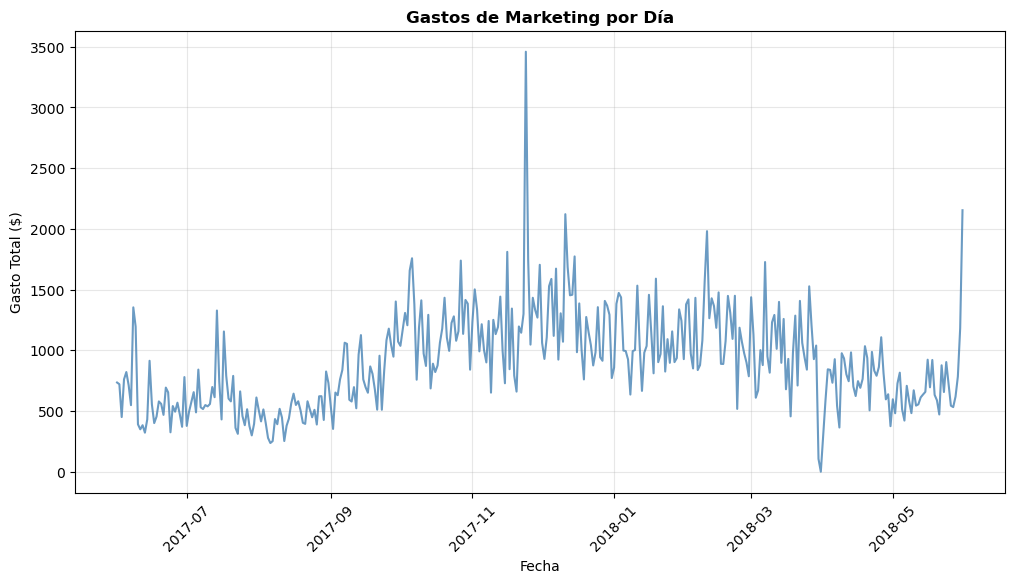

In [71]:
# Gráfico: Gastos por día
plt.figure(figsize=(12, 6))
plt.plot(pd.to_datetime(daily_costs['date']), daily_costs['total_costs'],
         color='steelblue', linewidth=1.5, alpha=0.8)
plt.title('Gastos de Marketing por Día', fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Gasto Total ($)')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.show()

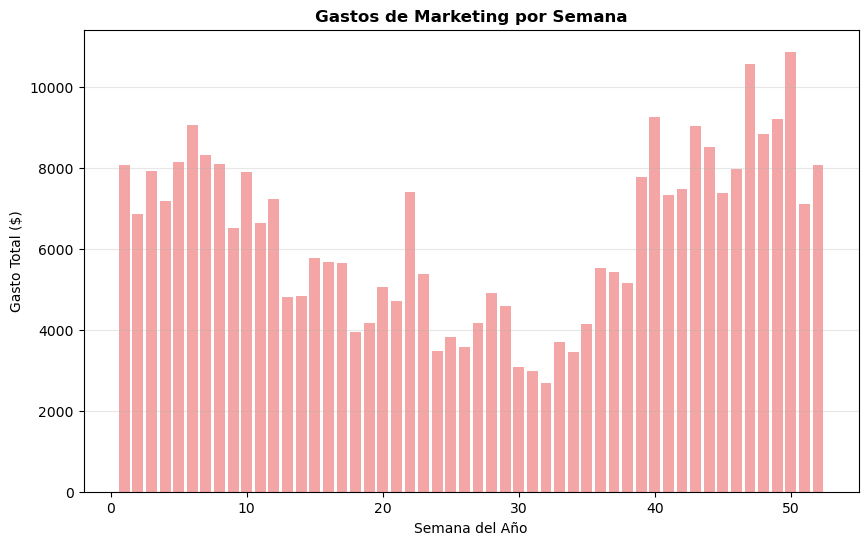

In [72]:
# Gráfico: gastos por semana
plt.figure(figsize=(10, 6))
plt.bar(weekly_costs['week'], weekly_costs['total_costs'],
         color='lightcoral', alpha=0.7)
plt.title('Gastos de Marketing por Semana', fontweight='bold')
plt.xlabel('Semana del Año')
plt.ylabel('Gasto Total ($)')
plt.grid(True, alpha=0.3, axis='y')
plt.show()

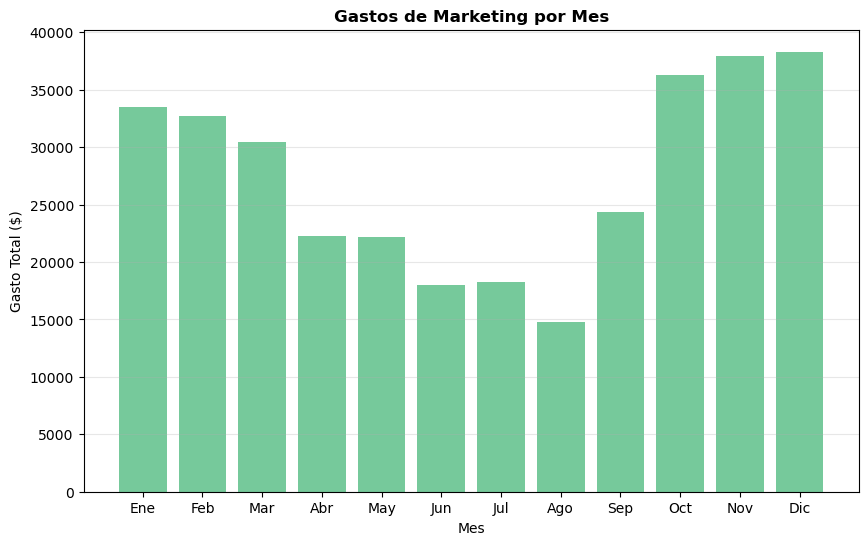

In [73]:
# Gráfico: Gastos por mes
month_names = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
               'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
plt.figure(figsize=(10, 6))
plt.bar(range(1, 13), monthly_costs['total_costs'],
         color='mediumseagreen', alpha=0.7)
plt.title('Gastos de Marketing por Mes', fontweight='bold')
plt.xlabel('Mes')
plt.ylabel('Gasto Total ($)')
plt.xticks(range(1, 13), month_names)
plt.grid(True, alpha=0.3, axis='y')
plt.show()

#### Conclusión — Inversión Total en Marketing

Durante el período analizado, el gasto total en marketing ascendió a **329,131.62 USD**, lo que representa una inversión constante a lo largo del tiempo. En promedio, se destinaron **904.21 USD por día**, **6,329.45 USD por semana** y **27,427.63 USD por mes**.

El análisis temporal muestra una distribución relativamente estable del gasto, con variaciones naturales entre días y semanas, mientras que la agregación mensual permite identificar patrones más claros de asignación presupuestaria.

Para la visualización de estos resultados:
- Se utilizaron **gráficos de línea** para analizar la evolución diaria del gasto.
- Se emplearon **gráficos de barras** para comparar los gastos semanales y mensuales.

Estos resultados establecen una base sólida para evaluar la **eficiencia del marketing**, al permitir contrastar la inversión realizada con métricas clave como conversión, revenue y LTV en los análisis posteriores.

#### 2.3.2. ¿Cuál fue el costo de adquisición de clientes de cada una de las fuentes?

In [74]:
# Gastos totales por fuente
costs_by_source = costs.groupby('source_id')['costs'].sum().sort_values(ascending=False)
print("=== GASTOS POR FUENTE DE ADQUISICIÓN ===")
for source, cost in costs_by_source.items():
    print(f"Fuente {source}: ${cost:,.2f}")

=== GASTOS POR FUENTE DE ADQUISICIÓN ===
Fuente 3: $141,321.63
Fuente 4: $61,073.60
Fuente 5: $51,757.10
Fuente 2: $42,806.04
Fuente 1: $20,833.27
Fuente 10: $5,822.49
Fuente 9: $5,517.49


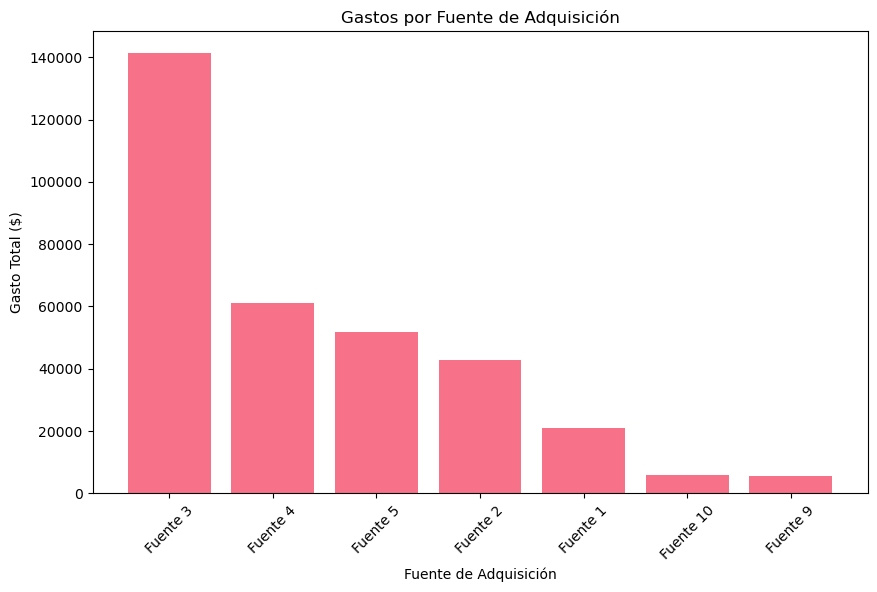

In [75]:
# Crear gráfico de barras 
plt.figure(figsize=(10, 6))
costs_by_source_sorted = costs_by_source.sort_values(ascending=False)
plt.bar(range(len(costs_by_source_sorted)), costs_by_source_sorted.values)
plt.xlabel('Fuente de Adquisición')
plt.ylabel('Gasto Total ($)')
plt.title('Gastos por Fuente de Adquisición')
plt.xticks(range(len(costs_by_source_sorted)), 
           [f'Fuente {i}' for i in costs_by_source_sorted.index])
plt.xticks(rotation=45)
plt.show()

In [76]:
# Obtener la fuente de la primera visita de cada usuario que compró
buyers_first_source = visits.merge(
    orders[['uid']].drop_duplicates(),  # Solo usuarios que compraron
    on='uid', 
    how='inner'
).groupby('uid')['source_id'].first().reset_index()

# Contar clientes únicos por fuente
clients_by_source = buyers_first_source['source_id'].value_counts().sort_index()
print("=== CLIENTES ÚNICOS POR FUENTE ===")
for source, clients in clients_by_source.items():
    print(f"Fuente {source}: {clients:,} clientes")

=== CLIENTES ÚNICOS POR FUENTE ===
Fuente 1: 3,743 clientes
Fuente 2: 4,323 clientes
Fuente 3: 9,138 clientes
Fuente 4: 9,823 clientes
Fuente 5: 6,839 clientes
Fuente 7: 1 clientes
Fuente 9: 1,415 clientes
Fuente 10: 1,241 clientes


In [77]:
# Calcular CAC por fuente
cac_by_source = costs_by_source / clients_by_source
cac_by_source = cac_by_source.dropna().sort_values()

print("\n=== COSTO DE ADQUISICIÓN DE CLIENTE (CAC) POR FUENTE ===")
for source, cac in cac_by_source.items():
    print(f"Fuente {source}: ${cac:.2f}")


=== COSTO DE ADQUISICIÓN DE CLIENTE (CAC) POR FUENTE ===
Fuente 9: $3.90
Fuente 10: $4.69
Fuente 1: $5.57
Fuente 4: $6.22
Fuente 5: $7.57
Fuente 2: $9.90
Fuente 3: $15.47


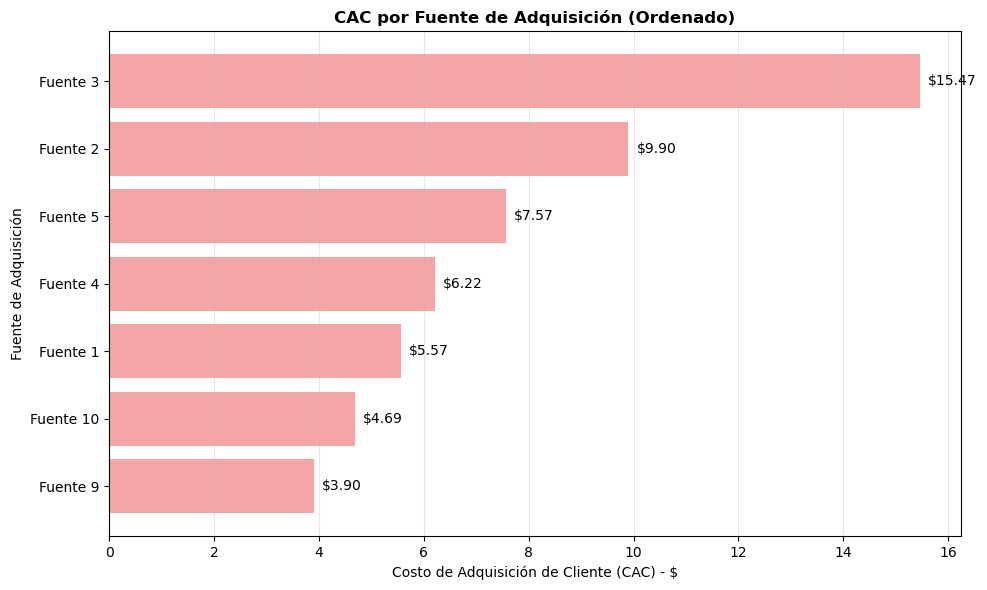

In [78]:
# Crear gráfico de barras horizontal 
plt.figure(figsize=(10, 6))
cac_sorted = cac_by_source.sort_values(ascending=True)  # Ascendente para que los altos queden arriba
plt.barh(range(len(cac_sorted)), cac_sorted.values, color='lightcoral', alpha=0.7)
plt.xlabel('Costo de Adquisición de Cliente (CAC) - $')
plt.ylabel('Fuente de Adquisición')
plt.title('CAC por Fuente de Adquisición (Ordenado)', fontweight='bold')
plt.yticks(range(len(cac_sorted)), [f'Fuente {i}' for i in cac_sorted.index])

# Agregar valores en las barras
for i, v in enumerate(cac_sorted.values):
    plt.text(v + max(cac_sorted.values) * 0.01, i, f'${v:.2f}', 
             va='center', ha='left', fontsize=10)

plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

### Conclusión — Costo de Adquisición de Clientes (CAC) por Fuente

El análisis del costo de adquisición de clientes muestra diferencias significativas en la eficiencia de las fuentes de marketing. Aunque algunas fuentes concentran el mayor volumen de gasto, no necesariamente son las más eficientes en términos de CAC.

Las fuentes con **menor CAC** son:
- **Fuente 9**: 3.90 USD  
- **Fuente 10**: 4.69 USD  
- **Fuente 1**: 5.57 USD  

Estas fuentes logran adquirir clientes a un costo reducido, lo que las convierte en canales altamente eficientes, aunque con menor volumen relativo de clientes.

En contraste, las fuentes con **mayor CAC** son:
- **Fuente 3**: 15.47 USD  
- **Fuente 2**: 9.90 USD  

Particularmente, la Fuente 3 concentra el mayor gasto total y un volumen elevado de clientes, pero presenta el CAC más alto, lo que sugiere una menor eficiencia en la adquisición.

Desde una perspectiva de negocio, estos resultados indican que:
- No todas las fuentes con alto gasto generan clientes de forma eficiente.
- Existe una oportunidad clara para **redistribuir presupuesto** hacia las fuentes con menor CAC.
- El análisis del CAC debe complementarse con métricas de **LTV y revenue** para evaluar no solo el costo de adquisición, sino la rentabilidad real de cada fuente.

Este análisis sienta las bases para evaluar la eficiencia global del marketing y optimizar la asignación del presupuesto en función del valor generado por cada canal.

#### 2.3.3. ¿Cuán rentables eran las inversiones?

In [79]:
# Obtener ganancias por fuente 
revenue_by_source = orders.merge(
    visits.groupby('uid')['source_id'].first().reset_index(),
    on='uid',
    how='left'
).groupby('source_id')['revenue'].sum().sort_index()

print("=== GANANCIAS TOTALES POR FUENTE ===")
for source, revenue in revenue_by_source.items():
    print(f"Fuente {source}: ${revenue:,.2f}")

=== GANANCIAS TOTALES POR FUENTE ===
Fuente 1: $38,560.06
Fuente 2: $65,152.26
Fuente 3: $44,317.68
Fuente 4: $52,479.75
Fuente 5: $40,357.91
Fuente 7: $1.22
Fuente 9: $7,076.98
Fuente 10: $4,111.34


In [80]:
# Calcular ROMI por fuente
romi_by_source = ((revenue_by_source - costs_by_source) / costs_by_source * 100).dropna()
romi_by_source = romi_by_source.sort_values(ascending=False)

print("\n=== RETURN ON MARKETING INVESTMENT (ROMI) POR FUENTE ===")
for source, romi in romi_by_source.items():
    print(f"Fuente {source}: {romi:.1f}%")


=== RETURN ON MARKETING INVESTMENT (ROMI) POR FUENTE ===
Fuente 1: 85.1%
Fuente 2: 52.2%
Fuente 9: 28.3%
Fuente 4: -14.1%
Fuente 5: -22.0%
Fuente 10: -29.4%
Fuente 3: -68.6%


In [81]:
# Crear tabla resumen con todas las métricas
marketing_summary = pd.DataFrame({
    'source_id': costs_by_source.index,
    'total_costs': costs_by_source.values,
    'total_revenue': [revenue_by_source.get(source, 0) for source in costs_by_source.index],
    'clients': [clients_by_source.get(source, 0) for source in costs_by_source.index],
    'cac': [cac_by_source.get(source, 0) for source in costs_by_source.index],
    'romi': [romi_by_source.get(source, 0) for source in costs_by_source.index]
})

print("\n=== RESUMEN COMPLETO DE MARKETING ===")
print(marketing_summary.round(2))


=== RESUMEN COMPLETO DE MARKETING ===
   source_id  total_costs  total_revenue  clients    cac   romi
0          3    141321.63       44317.68     9138  15.47 -68.64
1          4     61073.60       52479.75     9823   6.22 -14.07
2          5     51757.10       40357.91     6839   7.57 -22.02
3          2     42806.04       65152.26     4323   9.90  52.20
4          1     20833.27       38560.06     3743   5.57  85.09
5         10      5822.49        4111.34     1241   4.69 -29.39
6          9      5517.49        7076.98     1415   3.90  28.26


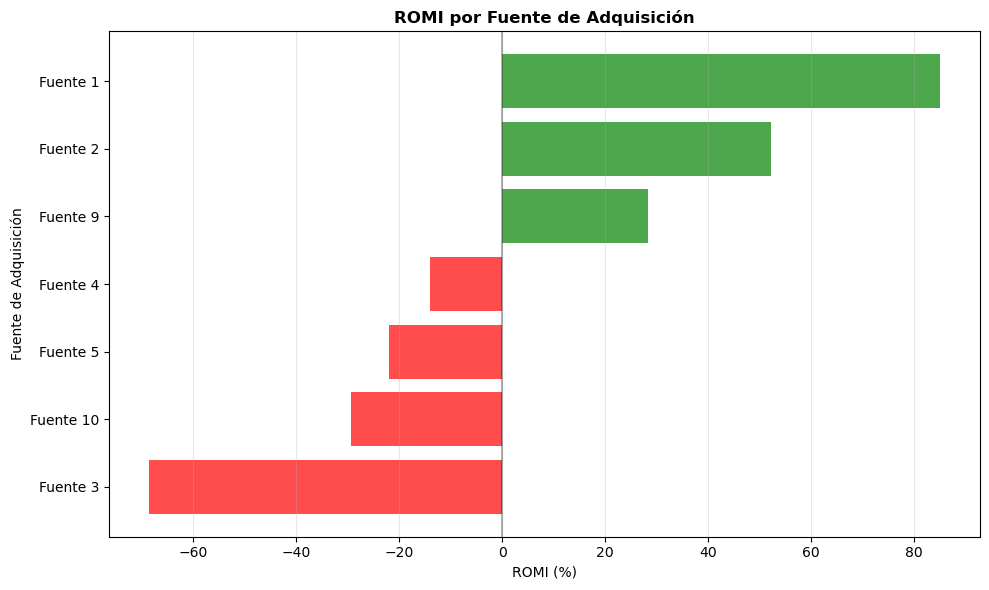

In [ ]:
# Gráfico de barras horizontal 
plt.figure(figsize=(10, 6))
romi_sorted = romi_by_source.sort_values(ascending=True)  # Valores altos arriba
colors = ['red' if x < 0 else 'green' for x in romi_sorted.values]
plt.barh(range(len(romi_sorted)), romi_sorted.values, color=colors, alpha=0.7)
plt.xlabel('ROMI (%)')
plt.ylabel('Fuente de Adquisición')
plt.title('ROMI por Fuente de Adquisición', fontweight='bold')
plt.yticks(range(len(romi_sorted)), [f'Fuente {i}' for i in romi_sorted.index])
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)  # Línea en cero
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(IMAGES_PATH / 'roi_by_source.png', dpi=150, bbox_inches='tight')
plt.show()

### Conclusión — Rentabilidad de las Inversiones en Marketing (ROMI)

El análisis del Return on Marketing Investment (ROMI) revela diferencias claras en la rentabilidad de las fuentes de adquisición, mostrando que no todas las inversiones generan valor para el negocio.

Las **fuentes con ROMI positivo** son:
- **Fuente 1**: 85.1%  
- **Fuente 2**: 52.2%  
- **Fuente 9**: 28.3%  

Estas fuentes generan ingresos superiores a su costo de adquisición, lo que indica una inversión rentable. En particular, la Fuente 1 destaca por combinar un CAC bajo con el ROMI más alto, convirtiéndose en el canal más eficiente y rentable del análisis.

En contraste, varias fuentes presentan **ROMI negativo**:
- **Fuente 4**: -14.1%  
- **Fuente 5**: -22.0%  
- **Fuente 10**: -29.4%  
- **Fuente 3**: -68.6%  

Aunque algunas de estas fuentes generan un volumen considerable de clientes (especialmente la Fuente 3 y la Fuente 4), los ingresos obtenidos no compensan la inversión realizada, lo que resulta en pérdidas netas desde la perspectiva de marketing.

El resumen completo confirma que un **mayor gasto o mayor volumen de clientes no garantiza rentabilidad**. Existen fuentes con CAC relativamente bajo pero ROMI negativo, lo que sugiere que el valor generado por cliente no es suficiente para cubrir los costos.

Desde una perspectiva de negocio, estos resultados indican que:
- El presupuesto debería priorizar las fuentes con **ROMI positivo y CAC competitivo**.
- Las fuentes con ROMI negativo requieren **optimización, reducción de inversión o reevaluación estratégica**.
- El análisis conjunto de **CAC, LTV y ROMI** es clave para tomar decisiones informadas sobre la asignación del presupuesto de marketing.

Este análisis permite identificar con claridad qué inversiones impulsan el crecimiento rentable del negocio y cuáles representan un costo sin retorno.

## Conclusión Final — Recomendaciones de Inversión en Marketing

### 1. Resumen Ejecutivo

El análisis integral de tráfico, ventas y marketing muestra que el crecimiento del negocio está impulsado principalmente por la **conversión inmediata**, un **alto volumen de compras pequeñas** y una **fuerte concentración del revenue en un grupo reducido de clientes y fuentes**.

Desde el punto de vista de marketing, no todas las fuentes generan valor de la misma forma. Algunas presentan **ROMI positivo y CAC bajo**, mientras que otras, a pesar de atraer volumen, generan **pérdidas netas**. Esto indica que la optimización del presupuesto debe enfocarse en **rentabilidad y eficiencia**, no únicamente en volumen de tráfico o clientes.

---

### 2. Recomendaciones de Inversión por Fuente

#### Fuentes a potenciar (ROMI positivo)

Se recomienda **incrementar o mantener la inversión** en las siguientes fuentes:

- **Fuente 1**  
  - ROMI: 85.1%  
  - CAC: 5.57 USD  
  - Alto retorno con bajo costo de adquisición  
- **Fuente 2**  
  - ROMI: 52.2%  
  - CAC: 9.90 USD  
  - Buen balance entre volumen y rentabilidad  
- **Fuente 9**  
  - ROMI: 28.3%  
  - CAC: 3.90 USD  
  - Fuente altamente eficiente, con margen para escalar  

Estas fuentes generan ingresos superiores a su costo y son responsables de la **creación de valor real para el negocio**.

#### Fuentes a optimizar o reducir (ROMI negativo)

Se recomienda **reducir inversión o pausar campañas** en las siguientes fuentes hasta corregir su desempeño:

- **Fuente 3** (ROMI: -68.6%)  
- **Fuente 10** (ROMI: -29.4%)  
- **Fuente 5** (ROMI: -22.0%)  
- **Fuente 4** (ROMI: -14.1%)

Aunque algunas de estas fuentes generan volumen de clientes, el **revenue obtenido no compensa el gasto**, lo que produce pérdidas desde la perspectiva de marketing.

#### Redistribución sugerida del presupuesto

- Redirigir parte del presupuesto de las fuentes con ROMI negativo hacia las fuentes 1, 2 y 9  
- Priorizar escalamiento controlado en las fuentes rentables, monitoreando CAC y LTV  
- Mantener pruebas limitadas en fuentes no rentables solo si existen hipótesis claras de optimización  

---

### 3. Métricas Clave que Fundamentan las Decisiones

Las recomendaciones se basan en las siguientes métricas:

- **CAC por fuente**: mide la eficiencia en la adquisición de clientes  
- **ROMI por fuente**: evalúa la rentabilidad real de cada inversión  
- **LTV**: revela una alta concentración del valor en un grupo reducido de clientes  
- **Patrones de conversión**: más del 70% de los usuarios compra el mismo día, lo que refuerza la importancia de captar intención inmediata  

El análisis conjunto de estas métricas permite distinguir entre **crecimiento aparente** y **crecimiento rentable**.

---

### 4. Estrategias Específicas

#### Para fuentes rentables
- Escalar inversión gradualmente
- Replicar mensajes y segmentaciones exitosas
- Optimizar la experiencia del primer día, donde ocurre la mayor conversión

#### Para fuentes no rentables
- Revisar calidad del tráfico y segmentación
- Ajustar mensajes, landing pages y timing
- Pausar inversión si no se logra mejorar ROMI

#### Oportunidades de mejora
- Enfocar campañas en usuarios con alta intención inmediata
- Implementar estrategias de upselling y retención para clientes de alto LTV
- Usar el LTV como métrica central para decisiones de inversión a mediano plazo

---

En conclusión, el negocio no necesita invertir más, sino **invertir mejor**. Priorizar fuentes con ROMI positivo, CAC eficiente y clientes de alto valor permitirá maximizar el impacto del presupuesto de marketing y sostener un crecimiento rentable a largo plazo.